# 이커머스 리뷰 감성 분석기
**유형:** 이진 분류형 (임베딩 + SVM/로지스틱 회귀 비교)  
**목표:** 이커머스 리뷰를 입력하면 긍정/부정 감성을 예측하는 AI 만들기

---
### 데이터 출처
- **Steam 게임 리뷰** (100,000건) — 라벨: 0(부정), 1(긍정)
- **네이버 쇼핑 리뷰** (200,000건) — 별점 1-2→부정(0), 4-5→긍정(1)
- 두 데이터를 합쳐 `reviews_merged.csv` (300,000건)로 통합

### 라벨 정의
| 라벨 | 의미 | 데이터 비율 |
|------|------|-------------|
| 0 | 부정 리뷰 | ~50% |
| 1 | 긍정 리뷰 | ~50% |

### 이 노트북의 구조
| 단계 | 내용 |
|------|------|
| Step 1 | 데이터 로드 및 탐색 |
| Step 2 | 데이터 전처리 |
| Step 3 | 임베딩 & 분류기 학습 (모델 비교) |
| Step 4 | 예측 & 평가 |
| Step 5 | 미니 미션 |

### 왜 이커머스 리뷰 감성 분석이 중요한가?
이커머스 리뷰 데이터는 실제 소비자의 생생한 의견을 담고 있습니다:
- 수십만 건의 리뷰를 사람이 직접 읽고 분류하는 것은 비현실적
- 감성 분석으로 **상품별 만족도 추이**, **부정 리뷰 알림**, **VOC 자동 분류** 가능
- 쇼핑+게임 두 도메인의 데이터를 함께 학습하여 **도메인 일반화 능력** 확인

## Step 1: 데이터 로드 및 탐색

In [2]:
# =============================================================================
# 1. 필수 라이브러리 설치 및 임포트
# =============================================================================
# [의도] 이 프로젝트에서 사용하는 모든 외부 라이브러리를 설치하고 불러옵니다.
#   - sentence-transformers: 텍스트를 고차원 벡터(임베딩)로 변환하는 사전학습 모델 라이브러리
#   - scikit-learn: 분류기(LogisticRegression, SVM) 학습 및 성능 평가 도구
#   - torch: sentence-transformers의 내부 연산을 위한 딥러닝 프레임워크(PyTorch)
# =============================================================================
!pip install sentence-transformers scikit-learn torch

# 양자화 및 LLM 구동을 위한 필수 라이브러리 설치
# 설치 후 '런타임 다시 시작'을 하지 않아도 되도록 최신 버전을 강제 설치합니다.
# !pip install -U bitsandbytes>=0.46.1
# !pip install -U transformers accelerate

# re: 텍스트 전처리 시 정규표현식으로 노이즈를 제거하기 위해 사용
import re

# pandas: 표 형태의 데이터(DataFrame)를 다루기 위한 핵심 라이브러리
# numpy: 임베딩 벡터 등 수치 배열 연산에 사용
import pandas as pd
import numpy as np

# Counter: 텍스트 중복 빈도를 세어 데이터 품질을 확인할 때 사용
from collections import Counter

In [3]:
# =============================================================================
# 1-1. 원본 데이터 로드 (개별 CSV 파일)
# =============================================================================
# [의도] 원본 개별 데이터셋을 로드하여 merge합니다.
#
# [왜 개별 파일을 로드하는가?]
#   - naver_shopping.csv, steam.csv는 각 출처별 원본 특성(별점 분포, 텍스트 스타일 등)을
#     개별적으로 탐색(EDA)하기 위해 별도로 로드합니다.
#   - 출처별 데이터의 구조와 품질을 독립적으로 확인해야
#     합쳐진 데이터에서 발생할 수 있는 문제(라벨 불균형, 텍스트 스타일 차이)를 사전에 파악할 수 있습니다.
#   - 향후 merge를 통해 합쳐진 데이터를 학습에 사용합니다.
#
# [파일 설명]
#   - naver_shopping.csv: 네이버 쇼핑 리뷰 20만건, 컬럼: rating(1~5), text
#   - steam.csv: Steam 게임 리뷰 10만건, 컬럼: label(0/1), text
# =============================================================================
naver_df = pd.read_csv("/content/naver_shopping.csv")     # EDA용 네이버 쇼핑 원본
steam_df = pd.read_csv("/content/steam.csv")              # EDA용 Steam 원본


In [4]:
# [EDA - 네이버 쇼핑 상위 5건]
# 데이터의 첫 5행을 확인하여 컬럼 구조(rating, text)와 데이터 형태를 직관적으로 파악합니다.
# 어떤 형식의 텍스트가 들어있는지 눈으로 확인하는 것이 EDA((Exploratory Data Analysis, 탐색적 데이터 분석)는 본격적인 모델링이나 전처리를 수행하기 전에 데이터의 구조, 분포, 품질, 이상치 등을 파악하는 분석 과정)의 첫 단계입니다.
naver_df.head(5)


,rating,text
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [5]:
# [EDA - 네이버 쇼핑 하위 5건]
# 마지막 5행을 확인하여 데이터가 끝까지 정상적으로 로드되었는지 검증합니다.
# 파일 끝에 손상된 행이나 NaN이 있을 수 있으므로 tail()로 확인합니다.
naver_df.tail(5)


,rating,text
199995,2,장마라그런가!!! 달지않아요
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요
199998,5,넘이쁘고 쎄련되보이네요~
199999,5,아직 사용해보지도않았고 다른 제품을 써본적이없어서 잘 모르겠지만 ㅎㅎ 배송은 빨랐습니다


In [6]:
# [EDA - 네이버 쇼핑 기술 통계]
# describe()는 수치형 컬럼(rating)의 기술 통계량을 보여줍니다.
# 별점 분포가 어떠한지(1점에 몰려있는지, 5점에 몰려있는지) 빠르게 파악할 수 있습니다.
# 이를 통해 긍정/부정 라벨 매핑(1-2→부정, 4-5→긍정) 시 균형을 예측합니다.
#
# [describe() 출력 행 설명]
#   count : 유효한 데이터 수 (NaN 제외). 전체 행 수와 차이가 나면 결측값이 있다는 의미
#   mean  : 평균값. rating의 mean이 3보다 크면 긍정 리뷰가 더 많다는 뜻
#   std   : 표준편차. 값이 클수록 별점이 넓게 퍼져 있음 (1점~5점 골고루 분포)
#   min   : 최솟값. rating의 최솟값이 1인지 확인 (데이터 범위 검증)
#   25%   : 1사분위수 (하위 25% 지점). 데이터의 하위 분포를 나타냄
#   50%   : 중앙값 (중위수). 평균과 차이가 크면 데이터가 한쪽으로 치우쳐 있음
#   75%   : 3사분위수 (상위 25% 지점). 데이터의 상위 분포를 나타냄
#   max   : 최댓값. rating의 최댓값이 5인지 확인 (이상치 여부 판단)
naver_df.describe()


,rating
count,200000.000000
mean,3.225275
std,1.645491
min,1.000000
25%,2.000000
50%,2.000000
75%,5.000000
max,5.000000


In [7]:
# [EDA - 네이버 쇼핑 데이터 구조]
# info()는 각 컬럼의 데이터 타입, Non-Null 개수, 메모리 사용량을 보여줍니다.
# NaN이 있는지, 숫자형이어야 할 컬럼이 문자열로 잘못 로드되지 않았는지 확인합니다.
# 20만건이 모두 정상 로드되었는지 총 행 수도 검증합니다.
naver_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   rating  200000 non-null  int64 
 1   text    200000 non-null  object
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [8]:
# [EDA - Steam 상위 5건]
# Steam 리뷰의 구조(label, text)를 확인합니다.
# Naver Shopping과 달리 라벨이 이미 0/1로 되어있는지,
# 게임 리뷰 특유의 텍스트 스타일(장문, 기술적 용어 등)을 파악합니다.
steam_df.head()


,label,text
0,0,노래가 너무 적음
1,0,"돌겠네 진짜. 황숙아, 어크 공장 그만 돌려라. 죽는다."
2,1,막노동 체험판 막노동 하는사람인데 장비를 내가 사야돼 뭐지
3,1,차악!차악!!차악!!! 정말 이래서 왕국을 되찾을 수 있는거야??
4,1,시간 때우기에 좋음.. 도전과제는 50시간이면 다 깰 수 있어요


In [10]:
# [EDA - Steam 하위 5건]
# 데이터 끝부분의 정상 여부를 확인합니다.
# 크롤링 데이터는 파일 끝에 불완전한 행이 포함될 수 있으므로 반드시 확인합니다.
steam_df.tail()


,label,text
99995,0,한글화해주면 10개산다
99996,0,개쌉노잼 ㅋㅋ
99997,0,노잼이네요... 30분하고 지웠어요...
99998,1,야생을 사랑하는 사람들을 위한 짧지만 여운이 남는 이야기. 영어는 그리 어렵지 않습니다.
99999,1,한국의 메탈레이지를 떠오르게한다 진짜 손맛으로 하는게임


In [12]:
# [EDA - Steam 기술 통계]
# label 컬럼의 평균값으로 긍정/부정 비율을 추정합니다.
# 평균이 0.5에 가까우면 균형잡힌 데이터, 한쪽으로 치우치면 불균형 데이터입니다.
# 불균형 시 학습에서 보정이 필요한지 미리 판단합니다.
#
# [describe() 출력 행 설명]
#   count : 유효한 데이터 수 (NaN 제외). 10만건이 모두 유효한지 확인
#   mean  : 평균값. label(0/1)의 mean이 0.5면 긍정:부정 = 1:1 완벽 균형
#   std   : 표준편차. 이진 라벨(0/1)이므로 약 0.5 근처가 정상
#   min   : 최솟값. label에 0 미만의 이상값이 없는지 확인
#   25%   : 1사분위수 (하위 25% 지점). 0이면 부정 데이터가 25% 이상 존재
#   50%   : 중앙값. 0이면 부정이 절반 이상, 1이면 긍정이 절반 이상
#   75%   : 3사분위수 (상위 25% 지점). 1이면 긍정 데이터가 25% 이상 존재
#   max   : 최댓값. label에 1 초과의 이상값이 없는지 확인
steam_df.describe()


,label
count,100000.000000
mean,0.499960
std,0.500002
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [13]:
# [EDA - Steam 데이터 구조]
# 10만건이 모두 정상 로드되었는지, NaN이 있는지, 데이터 타입이 올바른지 확인합니다.
# text 컬럼이 object(문자열)이고 label이 int인지 검증합니다.
steam_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   label   100000 non-null  int64 
 1   text    100000 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.5+ MB


In [81]:
# [EDA - 통합 데이터 구조]
# naver_df와 steam_df를 merge하여 통합본 사용

# Naver 데이터 전처리(별점): rating(1~5) -> label(0/1)
# 1, 2점 -> 0 (부정) / 4, 5점 -> 1 (긍정)
naver_df['label'] = np.nan
naver_df.loc[naver_df['rating'] <= 2, 'label'] = 0
naver_df.loc[naver_df['rating'] >= 4, 'label'] = 1

# 3점 처리: 0과 1로 균등하게 분배
mask_3 = naver_df['rating'] == 3
indices_3 = naver_df[mask_3].index
half = len(indices_3) // 2

# 절반은 0, 나머지는 1로 할당
naver_df.loc[indices_3[:half], 'label'] = 0
naver_df.loc[indices_3[half:], 'label'] = 1

# 라벨 타입을 정수(int)로 변환하고 출처 정보 추가
naver_df['label'] = naver_df['label'].astype(int)
naver_df['source'] = 'naver_shopping'

# Steam 데이터 전처리
steam_df['source'] = 'steam'

# 데이터 통합 (Steam부터 merge)
# 컬럼 순서 설정: text, label, source
columns_order = ['text', 'label', 'source']

raw_df = pd.concat([
    steam_df[columns_order],
    naver_df[columns_order]
], ignore_index=True)

# 30만건(Naver 20만 + Steam 10만)이 모두 합쳐졌는지,
# text, label, source 3개 컬럼이 정상적으로 존재하는지 검증합니다.
# 이 데이터가 이후 전처리와 학습에 직접 사용됩니다.
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    300000 non-null  object
 1   label   300000 non-null  int64 
 2   source  300000 non-null  object
dtypes: int64(1), object(2)
memory usage: 6.9+ MB


In [82]:
# =============================================================================
# 2. 이커머스 리뷰 데이터 로드 (CSV -> DataFrame)
# =============================================================================
# [의도] 사전에 합쳐 놓은 reviews_merged.csv를 로드하여 기본 분포를 확인합니다.
#
# [데이터 구조]
#   - text: 리뷰 텍스트 (한국어)
#   - label: 감성 라벨 (0=부정, 1=긍정)
#   - source: 데이터 출처 (steam / naver_shopping)
#
# [데이터 합성 과정] (reviews_merged.csv 생성 시)
#   - Steam: 원본 라벨(0/1)을 그대로 사용
#   - Naver Shopping: 별점 1-2 -> 0(부정), 별점 4-5 -> 1(긍정)으로 매핑
# =============================================================================

# [NaN 처리] text나 label이 비어있는 행은 감성 분류에 사용할 수 없으므로 제거합니다.
before_drop = len(raw_df)
raw_df = raw_df.dropna(subset=["text", "label"]).reset_index(drop=True)
raw_df["label"] = raw_df["label"].astype(int)

print(f"전체 데이터: {len(raw_df):,}건 (NaN 제거: {before_drop - len(raw_df)}건)\n")

# 소스별 분포: 두 데이터셋의 비율을 확인합니다.
print("=== 소스별 분포 ===")
print(raw_df["source"].value_counts())

# 라벨별 분포: 긍정/부정의 균형을 확인합니다.
# 불균형이 심하면 분류기가 다수 클래스로 편향될 수 있습니다.
print("\n=== 라벨 분포 ===")
label_counts = raw_df["label"].value_counts().sort_index()
label_counts.index = [f"{i} ({'부정' if i == 0 else '긍정'})" for i in label_counts.index]

print(label_counts)
print(pd.crosstab(raw_df["source"], raw_df["label"], margins=True))

print("\n=== 소스 x 라벨 교차표 ===")
# 교차표: 소스별로 긍정/부정 비율이 다른지 확인합니다.
cross_tab = pd.crosstab(raw_df["source"], raw_df["label"])
cross_tab.columns = ["부정 (0)", "긍정 (1)"]
cross_tab["합계"] = cross_tab.sum(axis=1)

ratio_tab = pd.crosstab(raw_df["source"], raw_df["label"], normalize="index") * 100
ratio_tab.columns = ["부정 비율(%)", "긍정 비율(%)"]

print(cross_tab)
print("\n=== 소스별 라벨 비율(%) ===")
print(ratio_tab.round(2))

전체 데이터: 300,000건 (NaN 제거: 0건)

=== 소스별 분포 ===
source
naver_shopping    200000
steam             100000
Name: count, dtype: int64

=== 라벨 분포 ===
0 (부정)    150041
1 (긍정)    149959
Name: count, dtype: int64
label                0       1     All
source                                
naver_shopping  100037   99963  200000
steam            50004   49996  100000
All             150041  149959  300000

=== 소스 x 라벨 교차표 ===
                부정 (0)  긍정 (1)      합계
source                                
naver_shopping  100037   99963  200000
steam            50004   49996  100000

=== 소스별 라벨 비율(%) ===
                부정 비율(%)  긍정 비율(%)
source                            
naver_shopping     50.02     49.98
steam              50.00     50.00


In [83]:
# =============================================================================
# 3. 원본 데이터 품질 확인 (전처리 전)
# =============================================================================
# [의도] 전처리를 적용하기 전에 원본 데이터의 품질 문제를 정량적으로 파악합니다.
# 이 분석 결과가 다음 셀에서 적용할 전처리 규칙의 근거가 됩니다.
#
# [확인 항목]
#   1) 결측값(NaN) 현황: 빈 텍스트/라벨이 있으면 학습 불가
#   2) 텍스트 길이 분포: 너무 짧은 텍스트는 감성 판단 단서 부족
#   3) 5자 미만 텍스트 샘플: 실제로 어떤 텍스트가 제거 대상인지 확인
#   4) 중복 텍스트: 동일 리뷰 반복은 과적합 위험
#   5) 특수문자/HTML 잔여물: 크롤링 시 남은 태그 확인
#   6) 소스별 텍스트 특성: Steam vs Naver의 리뷰 스타일 차이
# =============================================================================
print("=" * 60)
print("  원본 데이터 품질 분석 리포트")
print("=" * 60)

# ─────────────────────────────────────────────────
# [1] 결측값(NaN) 현황
# ─────────────────────────────────────────────────
# [판단 근거] NaN이 있는 행은 임베딩 변환이 불가하므로 반드시 제거해야 합니다.
print("\n[1] 결측값(NaN) 현황")
nan_text = raw_df["text"].isna().sum()
nan_label = raw_df["label"].isna().sum()
nan_source = raw_df["source"].isna().sum()
print(f"  text 컬럼 NaN: {nan_text:,}건")
print(f"  label 컬럼 NaN: {nan_label:,}건")
print(f"  source 컬럼 NaN: {nan_source:,}건")
if nan_text + nan_label == 0:
    print("  → 결측값 없음. 별도 처리 불필요.")
else:
    print(f"  → 총 {nan_text + nan_label:,}건 제거 필요")

# ─────────────────────────────────────────────────
# [2] 텍스트 길이 분포
# ─────────────────────────────────────────────────
# [판단 근거] 텍스트 길이 분포를 통해 최소 길이 기준(min_length)을 결정합니다.
# 평균/중앙값 대비 극단적으로 짧은 텍스트가 얼마나 있는지 파악합니다.
lengths = raw_df["text"].astype(str).str.len()
print(f"\n[2] 텍스트 길이 분포")
print(f"  평균: {lengths.mean():.1f}자")
print(f"  중앙값: {lengths.median():.0f}자")
print(f"  표준편차: {lengths.std():.1f}자")
print(f"  최소: {lengths.min()}자 / 최대: {lengths.max()}자")
print(f"  Q1(25%): {lengths.quantile(0.25):.0f}자 / Q3(75%): {lengths.quantile(0.75):.0f}자")

# 길이 구간별 분포: 어떤 길이대에 데이터가 집중되는지 확인
print(f"\n  [길이 구간별 분포]")
bins = [(0, 5), (5, 10), (10, 20), (20, 50), (50, 100), (100, 200), (200, float('inf'))]
for low, high in bins:
    mask = (lengths >= low) & (lengths < high)
    count = mask.sum()
    pct = count / len(lengths) * 100
    label = f"{low}~{int(high) if high != float('inf') else '∞'}자"
    bar = "█" * int(pct / 2)
    print(f"    {label:<12} {count:>8,}건 ({pct:>5.1f}%) {bar}")

  원본 데이터 품질 분석 리포트

[1] 결측값(NaN) 현황
  text 컬럼 NaN: 0건
  label 컬럼 NaN: 0건
  source 컬럼 NaN: 0건
  → 결측값 없음. 별도 처리 불필요.

[2] 텍스트 길이 분포
  평균: 42.0자
  중앙값: 31자
  표준편차: 31.7자
  최소: 1자 / 최대: 140자
  Q1(25%): 17자 / Q3(75%): 59자

  [길이 구간별 분포]
    0~5자            2,051건 (  0.7%) 
    5~10자          12,462건 (  4.2%) ██
    10~20자         75,912건 ( 25.3%) ████████████
    20~50자        113,711건 ( 37.9%) ██████████████████
    50~100자        73,244건 ( 24.4%) ████████████
    100~200자       22,620건 (  7.5%) ███
    200~∞자              0건 (  0.0%) 


In [84]:
# ─────────────────────────────────────────────────
# [3] 5자 미만 텍스트 상세 분석
# ─────────────────────────────────────────────────
# [판단 근거] "좋아", "별로" 같은 극히 짧은 리뷰는
# 임베딩 모델이 문맥을 파악하기 어렵고, 감성 분류에 필요한 정보가 부족합니다.
# 실제 샘플을 확인하여 5자 기준이 적절한지 검증합니다.
short_mask = lengths < 5
print(f"\n[3] 5자 미만 텍스트 분석")
print(f"  대상: {short_mask.sum():,}건 ({short_mask.mean()*100:.2f}%)")
if short_mask.sum() > 0:
    short_samples = raw_df.loc[short_mask, ["text", "label", "source"]].head(10)
    print(f"  샘플 (최대 10건):")
    for _, r in short_samples.iterrows():
        lbl = "부정" if r["label"] == 0 else "긍정"
        print(f"    [{lbl}] \"{r['text']}\" (출처: {r['source']})")
    # 5자 미만 중 라벨 분포
    short_label_dist = raw_df.loc[short_mask, "label"].value_counts().sort_index()
    print(f"  5자 미만 라벨 분포: 부정 {short_label_dist.get(0, 0):,}건, 긍정 {short_label_dist.get(1, 0):,}건")
    print(f"  → 제거해도 라벨 균형에 큰 영향 없음을 확인")


[3] 5자 미만 텍스트 분석
  대상: 2,051건 (0.68%)
  샘플 (최대 10건):
    [부정] "우웩" (출처: steam)
    [부정] "서든?" (출처: steam)
    [부정] "구림" (출처: steam)
    [긍정] "개좋음" (출처: steam)
    [긍정] "쟝게파" (출처: steam)
    [부정] "ㅈ같다" (출처: steam)
    [부정] "8비트" (출처: steam)
    [부정] "정신병" (출처: steam)
    [부정] "쒸익쒸익" (출처: steam)
    [긍정] "재미져요" (출처: steam)
  5자 미만 라벨 분포: 부정 1,046건, 긍정 1,005건
  → 제거해도 라벨 균형에 큰 영향 없음을 확인


In [85]:
# ─────────────────────────────────────────────────
# [4] 중복 텍스트 분석
# ─────────────────────────────────────────────────
# [판단 근거] 동일한 리뷰가 여러 번 등장하면 모델이 특정 표현에
# 과적합(overfitting)될 위험이 있습니다. 중복률과 실제 예시를 확인합니다.
text_counter = Counter(raw_df["text"].astype(str))
dup_texts = {t: c for t, c in text_counter.items() if c > 1}
total_dup = sum(c - 1 for c in dup_texts.values())
print(f"\n[4] 중복 텍스트 분석")
print(f"  고유 텍스트 수: {len(text_counter):,}건")
print(f"  중복이 있는 텍스트 종류: {len(dup_texts):,}건")
print(f"  중복으로 제거될 건수: {total_dup:,}건 ({total_dup/len(raw_df)*100:.2f}%)")
print(f"  가장 빈번한 중복 텍스트 (상위 5개):")
for text, count in sorted(dup_texts.items(), key=lambda x: -x[1])[:5]:
    print(f"    [{count}회] \"{text[:60]}{'...' if len(text) > 60 else ''}\"")


[4] 중복 텍스트 분석
  고유 텍스트 수: 299,789건
  중복이 있는 텍스트 종류: 209건
  중복으로 제거될 건수: 211건 (0.07%)
  가장 빈번한 중복 텍스트 (상위 5개):
    [3회] "사지마세요"
    [3회] "생각보다 그저그래요"
    [2회] "컨텐츠가 없네"
    [2회] "재미없다"
    [2회] "오류"


In [86]:
# ─────────────────────────────────────────────────
# [5] HTML 태그 및 특수 패턴 잔여물 확인
# ─────────────────────────────────────────────────
# [판단 근거] 웹 크롤링으로 수집된 데이터에는 HTML 태그(<br>, <b> 등)가
# 남아있을 수 있습니다. 이런 노이즈는 임베딩 품질을 저하시킵니다.
html_mask = raw_df["text"].astype(str).str.contains(r"<[^>]+>", regex=True, na=False)
# PyArrow 백엔드는 역참조(\1)를 지원하지 않으므로, 대표적인 반복 문자를 직접 열거합니다.
repeat_mask = raw_df["text"].astype(str).str.contains(
    r"ㅋ{5,}|ㅎ{5,}|ㅠ{5,}|ㅜ{5,}|ㅡ{5,}|\.{5,}|!{5,}|\?{5,}", regex=True, na=False
)
print(f"\n[5] HTML 태그 및 특수 패턴 잔여물")
print(f"  HTML 태그 포함: {html_mask.sum():,}건 ({html_mask.mean()*100:.2f}%)")
if html_mask.sum() > 0:
    print(f"  HTML 태그 예시:")
    for t in raw_df.loc[html_mask, "text"].head(3):
        print(f"    \"{str(t)[:80]}...\"")
print(f"  5자 이상 반복 문자 포함: {repeat_mask.sum():,}건 ({repeat_mask.mean()*100:.2f}%)")
if repeat_mask.sum() > 0:
    print(f"  반복 문자 예시:")
    for t in raw_df.loc[repeat_mask, "text"].head(3):
        print(f"    \"{str(t)[:80]}...\"")


[5] HTML 태그 및 특수 패턴 잔여물
  HTML 태그 포함: 4건 (0.00%)
  HTML 태그 예시:
    "레이스 다 풀리고 길 가다 개꼽당햇어용 >_< 착용 전에 안 봐서 환불은 못 하고 다 뜯겼움 ㅋㅋㅋ 같이 있는 친구가 옷가게 하는데 이건 마감 ..."
    "물건이 녹이 슬었는데도 교환 환불을 안해주는 그런 판매자에요ㅡ_ㅡ^ 사유가 1주일이 넘어서라네요,,, (여행다녀와서 물건을 늦게 확인했다고 톡톡..."
    "오성 변성우레탄실리콘인데 받은제품은 우레탄이 빠진 <변성실리콘>이라고 표기되어 있네요. 그냥 수성실리콘 인것같네요..."
  5자 이상 반복 문자 포함: 4,547건 (1.52%)
  반복 문자 예시:
    "서든어택 표절함 ㅋㅋㅋㅋㅋ 서든어택도 총쏘고 움직이고 한방에죽는데 이겜이 배낌 에혀 개노잼망겜이 다이렇지 븅쉬갬 ㅋ..."
    ".............열차+루트 같이 묶어서 파는게 좋을것 같네요 초보자들은 진짜 헤매거든요;;;;..."
    "지금 해도 꿀잼인데 지금 해도 멀미남 으아 못하게썽 ㅠㅠㅠㅠㅠㅠㅠㅠㅠㅠ..."


In [87]:
# ─────────────────────────────────────────────────
# [6] 소스별 텍스트 특성 비교
# ─────────────────────────────────────────────────
# [판단 근거] Steam 리뷰는 게임 경험을 서술하므로 비교적 길고,
# Naver Shopping 리뷰는 간단한 한줄평이 많아 짧은 경향이 있습니다.
# 두 출처의 특성 차이를 파악하여 전처리 기준이 한쪽에 편향되지 않도록 합니다.
print(f"\n[6] 소스별 텍스트 특성 비교")
print(f"  {'소스':<18} {'건수':>8} {'평균':>8} {'중앙값':>8} {'5자미만':>8} {'중복률':>8}")
print(f"  {'-'*58}")
for src in raw_df["source"].unique():
    src_df = raw_df[raw_df["source"] == src]
    src_len = src_df["text"].astype(str).str.len()
    src_short = (src_len < 5).sum()
    src_dup = len(src_df) - src_df["text"].nunique()
    print(f"  {str(src):<18} {len(src_df):>8,} {src_len.mean():>7.0f}자 {src_len.median():>7.0f}자 {src_short:>7,}건 {src_dup/len(src_df)*100:>6.1f}%")

print(f"\n{'=' * 60}")
print(f"  분석 결론: 전처리 규칙 결정 근거")
print(f"{'=' * 60}")
print(f"  1. NaN 제거 → text/label이 없으면 학습 불가")
print(f"  2. HTML 태그 제거 → 크롤링 잔여물이 임베딩 품질 저하")
print(f"  3. 반복 문자 축소 → 'ㅋㅋㅋㅋ'는 'ㅋㅋ'과 의미 동일")
print(f"  4. 5자 미만 제거 → 감성 판단 단서 부족 ({short_mask.sum():,}건, {short_mask.mean()*100:.2f}%)")
print(f"  5. 완전 중복 제거 → 과적합 방지 ({total_dup:,}건)")
print(f"  6. 다중 공백 정리 → 텍스트 정규화")


[6] 소스별 텍스트 특성 비교
  소스                       건수       평균      중앙값     5자미만      중복률
  ----------------------------------------------------------
  steam               100,000      47자      36자   2,048건    0.1%
  naver_shopping      200,000      40자      29자       3건    0.0%

  분석 결론: 전처리 규칙 결정 근거
  1. NaN 제거 → text/label이 없으면 학습 불가
  2. HTML 태그 제거 → 크롤링 잔여물이 임베딩 품질 저하
  3. 반복 문자 축소 → 'ㅋㅋㅋㅋ'는 'ㅋㅋ'과 의미 동일
  4. 5자 미만 제거 → 감성 판단 단서 부족 (2,051건, 0.68%)
  5. 완전 중복 제거 → 과적합 방지 (211건)
  6. 다중 공백 정리 → 텍스트 정규화


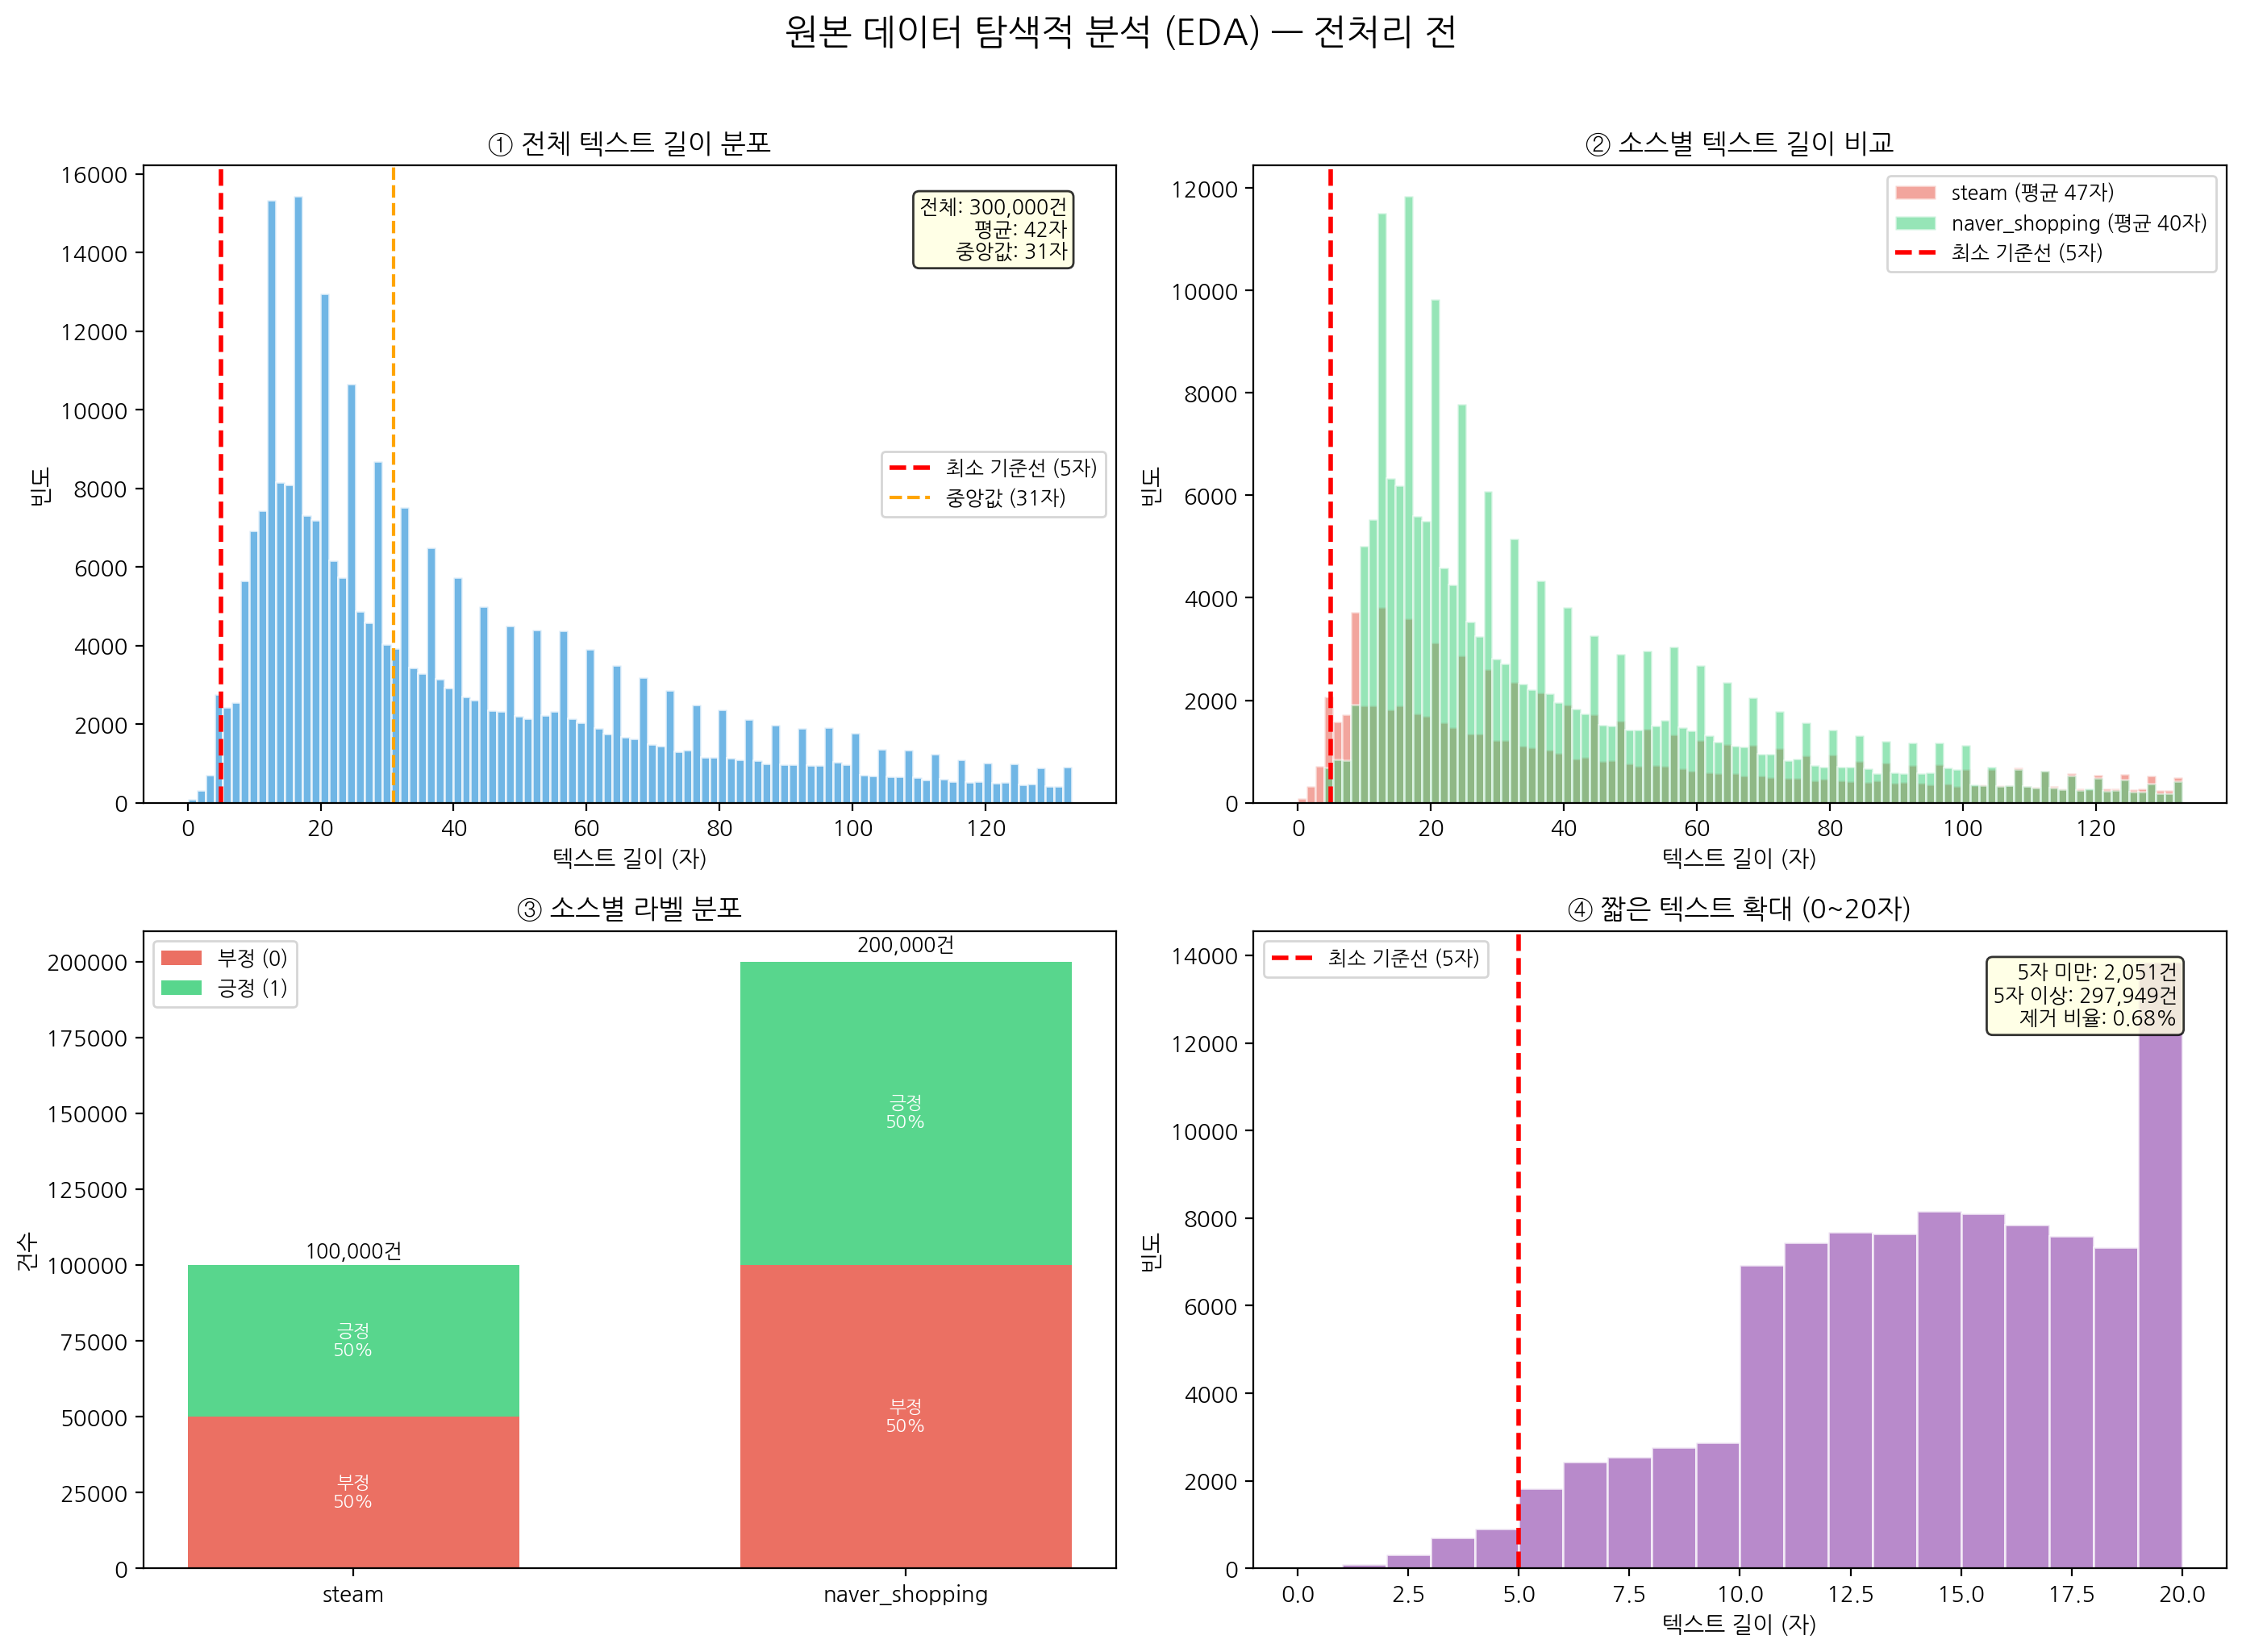

In [88]:
# =============================================================================
# 3-1. 원본 데이터 시각화 (전처리 전 EDA)
# =============================================================================
# [의도] 위 품질 분석 결과를 시각적으로 확인합니다.
# 숫자만으로는 파악하기 어려운 분포의 형태(skewness, 이상치 등)를
# 히스토그램과 차트로 직관적으로 보여줍니다.
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# [Colab 환경 한글 폰트 설정]
import matplotlib.font_manager as fm  # 폰트 관리를 위한 모듈 추가

# 한글 폰트 강제 설치 및 재캐싱
!apt-get -qq -y install fonts-nanum > /dev/null

# 설치된 나눔 폰트 자동 검색 및 설정
# 직접 경로 대신 시스템에 등록된 폰트 중 'Nanum'이 들어간 폰트를 찾습니다.
fe = fm.FontEntry(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe) # 리스트 맨 앞에 추가
plt.rc('font', family='NanumGothic')

# 마이너스 기호 및 해상도 설정
matplotlib.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('원본 데이터 탐색적 분석 (EDA) — 전처리 전', fontsize=16, fontweight='bold', y=1.02)

# ─────────────────────────────────────────────────
# [차트 1] 전체 텍스트 길이 분포 히스토그램
# ─────────────────────────────────────────────────
# [판단 근거] 텍스트 길이의 전체적인 분포 형태를 파악합니다.
# 왼쪽으로 치우친(right-skewed) 분포라면 짧은 리뷰가 많다는 뜻이며,
# 최소 길이 기준을 설정할 때 참고합니다.
ax1 = axes[0, 0]
lengths = raw_df["text"].astype(str).str.len()
# 99번째 백분위수를 기준으로 X축 범위를 설정하여 분포를 선명하게 표시합니다.
x_max = int(lengths.quantile(0.99))
ax1.hist(lengths, bins=100, range=(0, x_max), color='#3498db', alpha=0.7, edgecolor='white')
ax1.axvline(x=5, color='red', linestyle='--', linewidth=2, label=f'최소 기준선 (5자)')
ax1.axvline(x=lengths.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값 ({lengths.median():.0f}자)')
ax1.set_xlabel('텍스트 길이 (자)')
ax1.set_ylabel('빈도')
ax1.set_title('① 전체 텍스트 길이 분포')
ax1.legend(fontsize=9)
ax1.text(0.95, 0.95, f'전체: {len(raw_df):,}건\n평균: {lengths.mean():.0f}자\n중앙값: {lengths.median():.0f}자',
         transform=ax1.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ─────────────────────────────────────────────────
# [차트 2] 소스별 텍스트 길이 분포 비교
# ─────────────────────────────────────────────────
# [판단 근거] Steam과 Naver Shopping의 리뷰 스타일이 다르므로,
# 전처리 기준(5자)이 특정 출처에만 편향되지 않는지 확인합니다.
ax2 = axes[0, 1]
colors_src = {'steam': '#e74c3c', 'naver_shopping': '#2ecc71'}
for src in raw_df["source"].unique():
    src_lengths = raw_df[raw_df["source"] == src]["text"].astype(str).str.len()
    ax2.hist(src_lengths, bins=100, range=(0, x_max), alpha=0.5,
             label=f'{src} (평균 {src_lengths.mean():.0f}자)',
             color=colors_src.get(str(src), '#95a5a6'), edgecolor='white')
ax2.axvline(x=5, color='red', linestyle='--', linewidth=2, label='최소 기준선 (5자)')
ax2.set_xlabel('텍스트 길이 (자)')
ax2.set_ylabel('빈도')
ax2.set_title('② 소스별 텍스트 길이 비교')
ax2.legend(fontsize=9)

# ─────────────────────────────────────────────────
# [차트 3] 라벨 분포 (소스별 Stacked Bar)
# ─────────────────────────────────────────────────
# [판단 근거] 긍정/부정 라벨의 균형을 확인합니다.
# 불균형이 심하면 분류기가 다수 클래스로 편향될 수 있으므로
# 균형 샘플링이 필요한지 판단합니다.
ax3 = axes[1, 0]
sources = raw_df["source"].unique()
x_pos = range(len(sources))
neg_counts = [len(raw_df[(raw_df["source"] == s) & (raw_df["label"] == 0)]) for s in sources]
pos_counts = [len(raw_df[(raw_df["source"] == s) & (raw_df["label"] == 1)]) for s in sources]
bars_neg = ax3.bar(x_pos, neg_counts, width=0.6, label='부정 (0)', color='#e74c3c', alpha=0.8)
bars_pos = ax3.bar(x_pos, pos_counts, width=0.6, bottom=neg_counts, label='긍정 (1)', color='#2ecc71', alpha=0.8)
ax3.set_xticks(list(x_pos))
ax3.set_xticklabels([str(s) for s in sources])
ax3.set_ylabel('건수')
ax3.set_title('③ 소스별 라벨 분포')
ax3.legend(fontsize=9)
for i, (n, p) in enumerate(zip(neg_counts, pos_counts)):
    total = n + p
    ax3.text(i, total + total*0.01, f'{total:,}건', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ratio = n / total * 100
    ax3.text(i, n/2, f'부정\n{ratio:.0f}%', ha='center', va='center', fontsize=8, color='white')
    ax3.text(i, n + p/2, f'긍정\n{100-ratio:.0f}%', ha='center', va='center', fontsize=8, color='white')

# ─────────────────────────────────────────────────
# [차트 4] 5자 미만 텍스트 길이 분포 (확대)
# ─────────────────────────────────────────────────
# [판단 근거] 최소 길이 기준(5자) 근처의 데이터를 확대하여
# 기준이 적절한지 세밀하게 확인합니다.
# 3~4자에 의미 있는 리뷰가 많다면 기준을 낮춰야 합니다.
ax4 = axes[1, 1]
short_lengths = lengths[lengths <= 20]
ax4.hist(short_lengths, bins=20, range=(0, 20), color='#9b59b6', alpha=0.7, edgecolor='white')
ax4.axvline(x=5, color='red', linestyle='--', linewidth=2, label='최소 기준선 (5자)')
ax4.set_xlabel('텍스트 길이 (자)')
ax4.set_ylabel('빈도')
ax4.set_title('④ 짧은 텍스트 확대 (0~20자)')
ax4.legend(fontsize=9)
short_count = (lengths < 5).sum()
ax4.text(0.95, 0.95, f'5자 미만: {short_count:,}건\n5자 이상: {len(lengths)-short_count:,}건\n제거 비율: {short_count/len(lengths)*100:.2f}%',
         transform=ax4.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

## Step 2: 데이터 전처리

이커머스 리뷰 데이터는 사용자가 직접 작성한 텍스트이므로 다음과 같은 노이즈가 존재합니다:

| 문제 | 예시 | 해결 방법 |
|------|------|-----------|
| HTML 태그 | `<br>`, `<b>` | 정규표현식으로 제거 |
| 반복 문자 | "너무 좋아요ㅋㅋㅋㅋㅋㅋ" | 3자 이상 반복을 2자로 축소 |
| 극히 짧은 텍스트 | "좋아", "별로" | 5자 미만 제거 |
| 불필요한 공백 | "  리뷰 텍스트  " | strip + 다중 공백 제거 |
| 완전 중복 | 동일 텍스트 반복 | drop_duplicates |

In [89]:
# =============================================================================
# 4. 텍스트 전처리 함수 정의 + 데이터프레임 전처리
# =============================================================================
# [의도] 이커머스 리뷰에 특화된 텍스트 정제 규칙을 적용합니다.
#
# [고객문의 분류기와의 차이점]
#   고객문의 분류기에서는 콜센터 통화 녹취 텍스트의 특성에 맞춰
#   "네", "아 그래요?" 같은 추임새 필터와 ㅇㅇㅇ 익명화 토큰 제거가 필요했습니다.
#   이커머스 리뷰는 사용자 직접 작성이므로 추임새가 없지만,
#   대신 HTML 태그, 반복 문자(ㅋㅋㅋ), 이모티콘 등의 노이즈가 존재합니다.
#
# [최소 길이 기준: 5자]
#   고객문의 분류기에서는 15자였으나, 이커머스 리뷰는 "가격 대비 좋아요" 같은
#   짧은 한줄평도 의미가 있으므로 5자로 낮게 설정합니다.
# =============================================================================

def clean_text(text):
    """
    이커머스 리뷰 텍스트를 정제합니다.

    [처리 순서]
    1) 문자열 변환: NaN이나 숫자 등 비문자열 입력을 안전하게 처리
    2) HTML 태그 제거: <br>, <b>, <p> 등 웹에서 크롤링된 태그 잔여물 제거
    3) 반복 문자 축소: "ㅋㅋㅋㅋㅋ" -> "ㅋㅋ", "좋아요요요요" -> "좋아요요"
       3자 이상 연속 동일 문자를 2자로 축소하여 텍스트 정규화
    4) 공백 정리: 다중 공백 -> 단일 공백, 앞뒤 공백 제거

    Args:
        text: 원본 리뷰 텍스트
    Returns:
        정제된 텍스트 문자열
    """
    # NaN이나 숫자 등 비문자열 입력을 문자열로 변환합니다.
    text = str(text)

    # HTML 태그 제거: 웹 크롤링으로 수집된 데이터에 남아있는 태그를 제거합니다.
    # 예: "<br>줄바꿈" -> "줄바꿈", "<b>강조</b>" -> "강조"
    text = re.sub(r"<[^>]+>", "", text)

    # 반복 문자 축소: 같은 문자가 3회 이상 반복되면 2회로 줄입니다.
    # 예: "좋아요ㅋㅋㅋㅋㅋ" -> "좋아요ㅋㅋ"
    # 이모티콘이나 감탄사의 과도한 반복을 정규화하여 임베딩 품질을 높입니다.
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # 다중 공백 -> 단일 공백: "좋은   제품" -> "좋은 제품"
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_dataframe(df, min_length=5):
    """
    DataFrame 전체에 전처리를 적용합니다.

    [처리 순서]
    1) clean_text()를 모든 텍스트에 적용
    2) 빈 문자열 제거
    3) min_length 미만 텍스트 제거 (감성 판단 단서 부족)
    4) 완전 중복 텍스트 제거 (과적합 방지)

    Args:
        df: text, label 컬럼이 있는 DataFrame
        min_length: 최소 텍스트 길이 (기본값 5)
    Returns:
        전처리된 DataFrame (원본은 변경하지 않음)
    """
    result = df.copy()
    original_len = len(result)

    # 모든 텍스트에 clean_text() 적용
    result["text"] = result["text"].apply(clean_text)

    # 빈 문자열 제거: clean_text 후 빈 문자열이 된 행을 제거합니다.
    result = result[result["text"].str.len() > 0]
    print(f"  -> 빈 텍스트 제거 후: {len(result):,}건 (-{original_len - len(result)})")

    # 최소 길이 미만 제거: 감성 판단에 필요한 최소한의 정보가 없는 텍스트를 제거합니다.
    before = len(result)
    result = result[result["text"].str.len() >= min_length]
    print(f"  -> {min_length}자 미만 제거 후: {len(result):,}건 (-{before - len(result):,})")

    # 완전 중복 제거: 동일한 텍스트가 여러 번 있으면 첫 번째만 남깁니다.
    before = len(result)
    result = result.drop_duplicates(subset="text", keep="first")
    print(f"  -> 중복 제거 후: {len(result):,}건 (-{before - len(result):,})")

    return result.reset_index(drop=True)


# 전처리 실행
print("데이터 전처리 중...")
print(f"  원본: {len(raw_df):,}건")
clean_df = preprocess_dataframe(raw_df, min_length=5)

데이터 전처리 중...
  원본: 300,000건
  -> 빈 텍스트 제거 후: 300,000건 (-0)
  -> 5자 미만 제거 후: 297,825건 (-2,175)
  -> 중복 제거 후: 297,641건 (-184)


In [90]:
# =============================================================================
# 5. 전처리 전후 비교 (정량 분석)
# =============================================================================
# [의도] 전처리가 데이터에 어떤 영향을 미쳤는지 다각도로 검증합니다.
# 전처리 후에도 라벨 균형이 유지되는지, 텍스트 길이가 적절히 변했는지 확인합니다.
# =============================================================================
print("=" * 60)
print("  전처리 전 vs 후 비교 리포트")
print("=" * 60)

# ─────────────────────────────────────────────────
# [1] 데이터 건수 변화
# ─────────────────────────────────────────────────
removed = len(raw_df) - len(clean_df)
print(f"\n[1] 데이터 건수 변화")
print(f"  전처리 전: {len(raw_df):,}건")
print(f"  전처리 후: {len(clean_df):,}건")
print(f"  제거된 데이터: {removed:,}건 ({removed/len(raw_df)*100:.2f}%)")
print(f"  → 전체의 {100 - removed/len(raw_df)*100:.1f}%를 보존하여 데이터 손실이 미미함")

  전처리 전 vs 후 비교 리포트

[1] 데이터 건수 변화
  전처리 전: 300,000건
  전처리 후: 297,641건
  제거된 데이터: 2,359건 (0.79%)
  → 전체의 99.2%를 보존하여 데이터 손실이 미미함


In [91]:
# ─────────────────────────────────────────────────
# [2] 텍스트 길이 변화
# ─────────────────────────────────────────────────
raw_lengths = raw_df["text"].astype(str).str.len()
clean_lengths = clean_df["text"].astype(str).str.len()
print(f"\n[2] 텍스트 길이 변화")
print(f"  {'구분':<12} {'평균':>8} {'중앙값':>8} {'최소':>6} {'최대':>6}")
print(f"  {'-'*44}")
print(f"  {'전처리 전':<12} {raw_lengths.mean():>7.0f}자 {raw_lengths.median():>7.0f}자 {raw_lengths.min():>5}자 {raw_lengths.max():>5}자")
print(f"  {'전처리 후':<12} {clean_lengths.mean():>7.0f}자 {clean_lengths.median():>7.0f}자 {clean_lengths.min():>5}자 {clean_lengths.max():>5}자")



[2] 텍스트 길이 변화
  구분                 평균      중앙값     최소     최대
  --------------------------------------------
  전처리 전             42자      31자     1자   140자
  전처리 후             42자      31자     5자   140자


In [92]:
# ─────────────────────────────────────────────────
# [3] 라벨 분포 변화 (편향 확인)
# ─────────────────────────────────────────────────
# [판단 근거] 전처리 과정에서 특정 라벨의 데이터가 편향되게 제거되면
# 분류 성능에 악영향을 줄 수 있으므로 반드시 검증해야 합니다.
print(f"\n[3] 라벨 분포 변화 (편향 확인)")
for lbl, name in [(0, "부정"), (1, "긍정")]:
    before_cnt = (raw_df["label"] == lbl).sum()
    after_cnt = (clean_df["label"] == lbl).sum()
    before_pct = before_cnt / len(raw_df) * 100
    after_pct = after_cnt / len(clean_df) * 100
    print(f"  {name}({lbl}): {before_cnt:,}건({before_pct:.1f}%) → {after_cnt:,}건({after_pct:.1f}%)  [차이: {abs(after_pct-before_pct):.2f}%p]")
print(f"  → 라벨 비율 변화가 미미하여 전처리로 인한 편향 없음 확인")


[3] 라벨 분포 변화 (편향 확인)
  부정(0): 150,041건(50.0%) → 148,782건(50.0%)  [차이: 0.03%p]
  긍정(1): 149,959건(50.0%) → 148,859건(50.0%)  [차이: 0.03%p]
  → 라벨 비율 변화가 미미하여 전처리로 인한 편향 없음 확인


In [93]:

# ─────────────────────────────────────────────────
# [4] 소스별 제거 비율
# ─────────────────────────────────────────────────
print(f"\n[4] 소스별 제거 비율")
for src in raw_df["source"].unique():
    before_cnt = (raw_df["source"] == src).sum()
    after_cnt = (clean_df["source"] == src).sum()
    removed_cnt = before_cnt - after_cnt
    print(f"  {str(src):<18}: {before_cnt:,}건 → {after_cnt:,}건 (제거: {removed_cnt:,}건, {removed_cnt/before_cnt*100:.2f}%)")


[4] 소스별 제거 비율
  steam             : 100,000건 → 97,806건 (제거: 2,194건, 2.19%)
  naver_shopping    : 200,000건 → 199,835건 (제거: 165건, 0.08%)


In [94]:

# ─────────────────────────────────────────────────
# [5] 실제 텍스트 변화 예시
# ─────────────────────────────────────────────────
# clean_text()가 실제로 어떻게 텍스트를 바꾸는지 구체적인 예시를 보여줍니다.
print(f"\n[5] clean_text() 적용 예시")
test_examples = [
    "너무 좋아요ㅋㅋㅋㅋㅋㅋ 강력 추천!!!",
    "<br>배송 빠르고   좋아요<br>",
    "ㅋㅋㅋㅋㅋ 최고!!!!!",
    "좋아",
]
for ex in test_examples:
    cleaned = clean_text(ex)
    changed = " (변화 없음)" if ex == cleaned else ""
    print(f"  원본: \"{ex}\"")
    print(f"  정제: \"{cleaned}\"{changed}")
    print()


[5] clean_text() 적용 예시
  원본: "너무 좋아요ㅋㅋㅋㅋㅋㅋ 강력 추천!!!"
  정제: "너무 좋아요ㅋㅋ 강력 추천!!"

  원본: "<br>배송 빠르고   좋아요<br>"
  정제: "배송 빠르고 좋아요"

  원본: "ㅋㅋㅋㅋㅋ 최고!!!!!"
  정제: "ㅋㅋ 최고!!"

  원본: "좋아"
  정제: "좋아" (변화 없음)



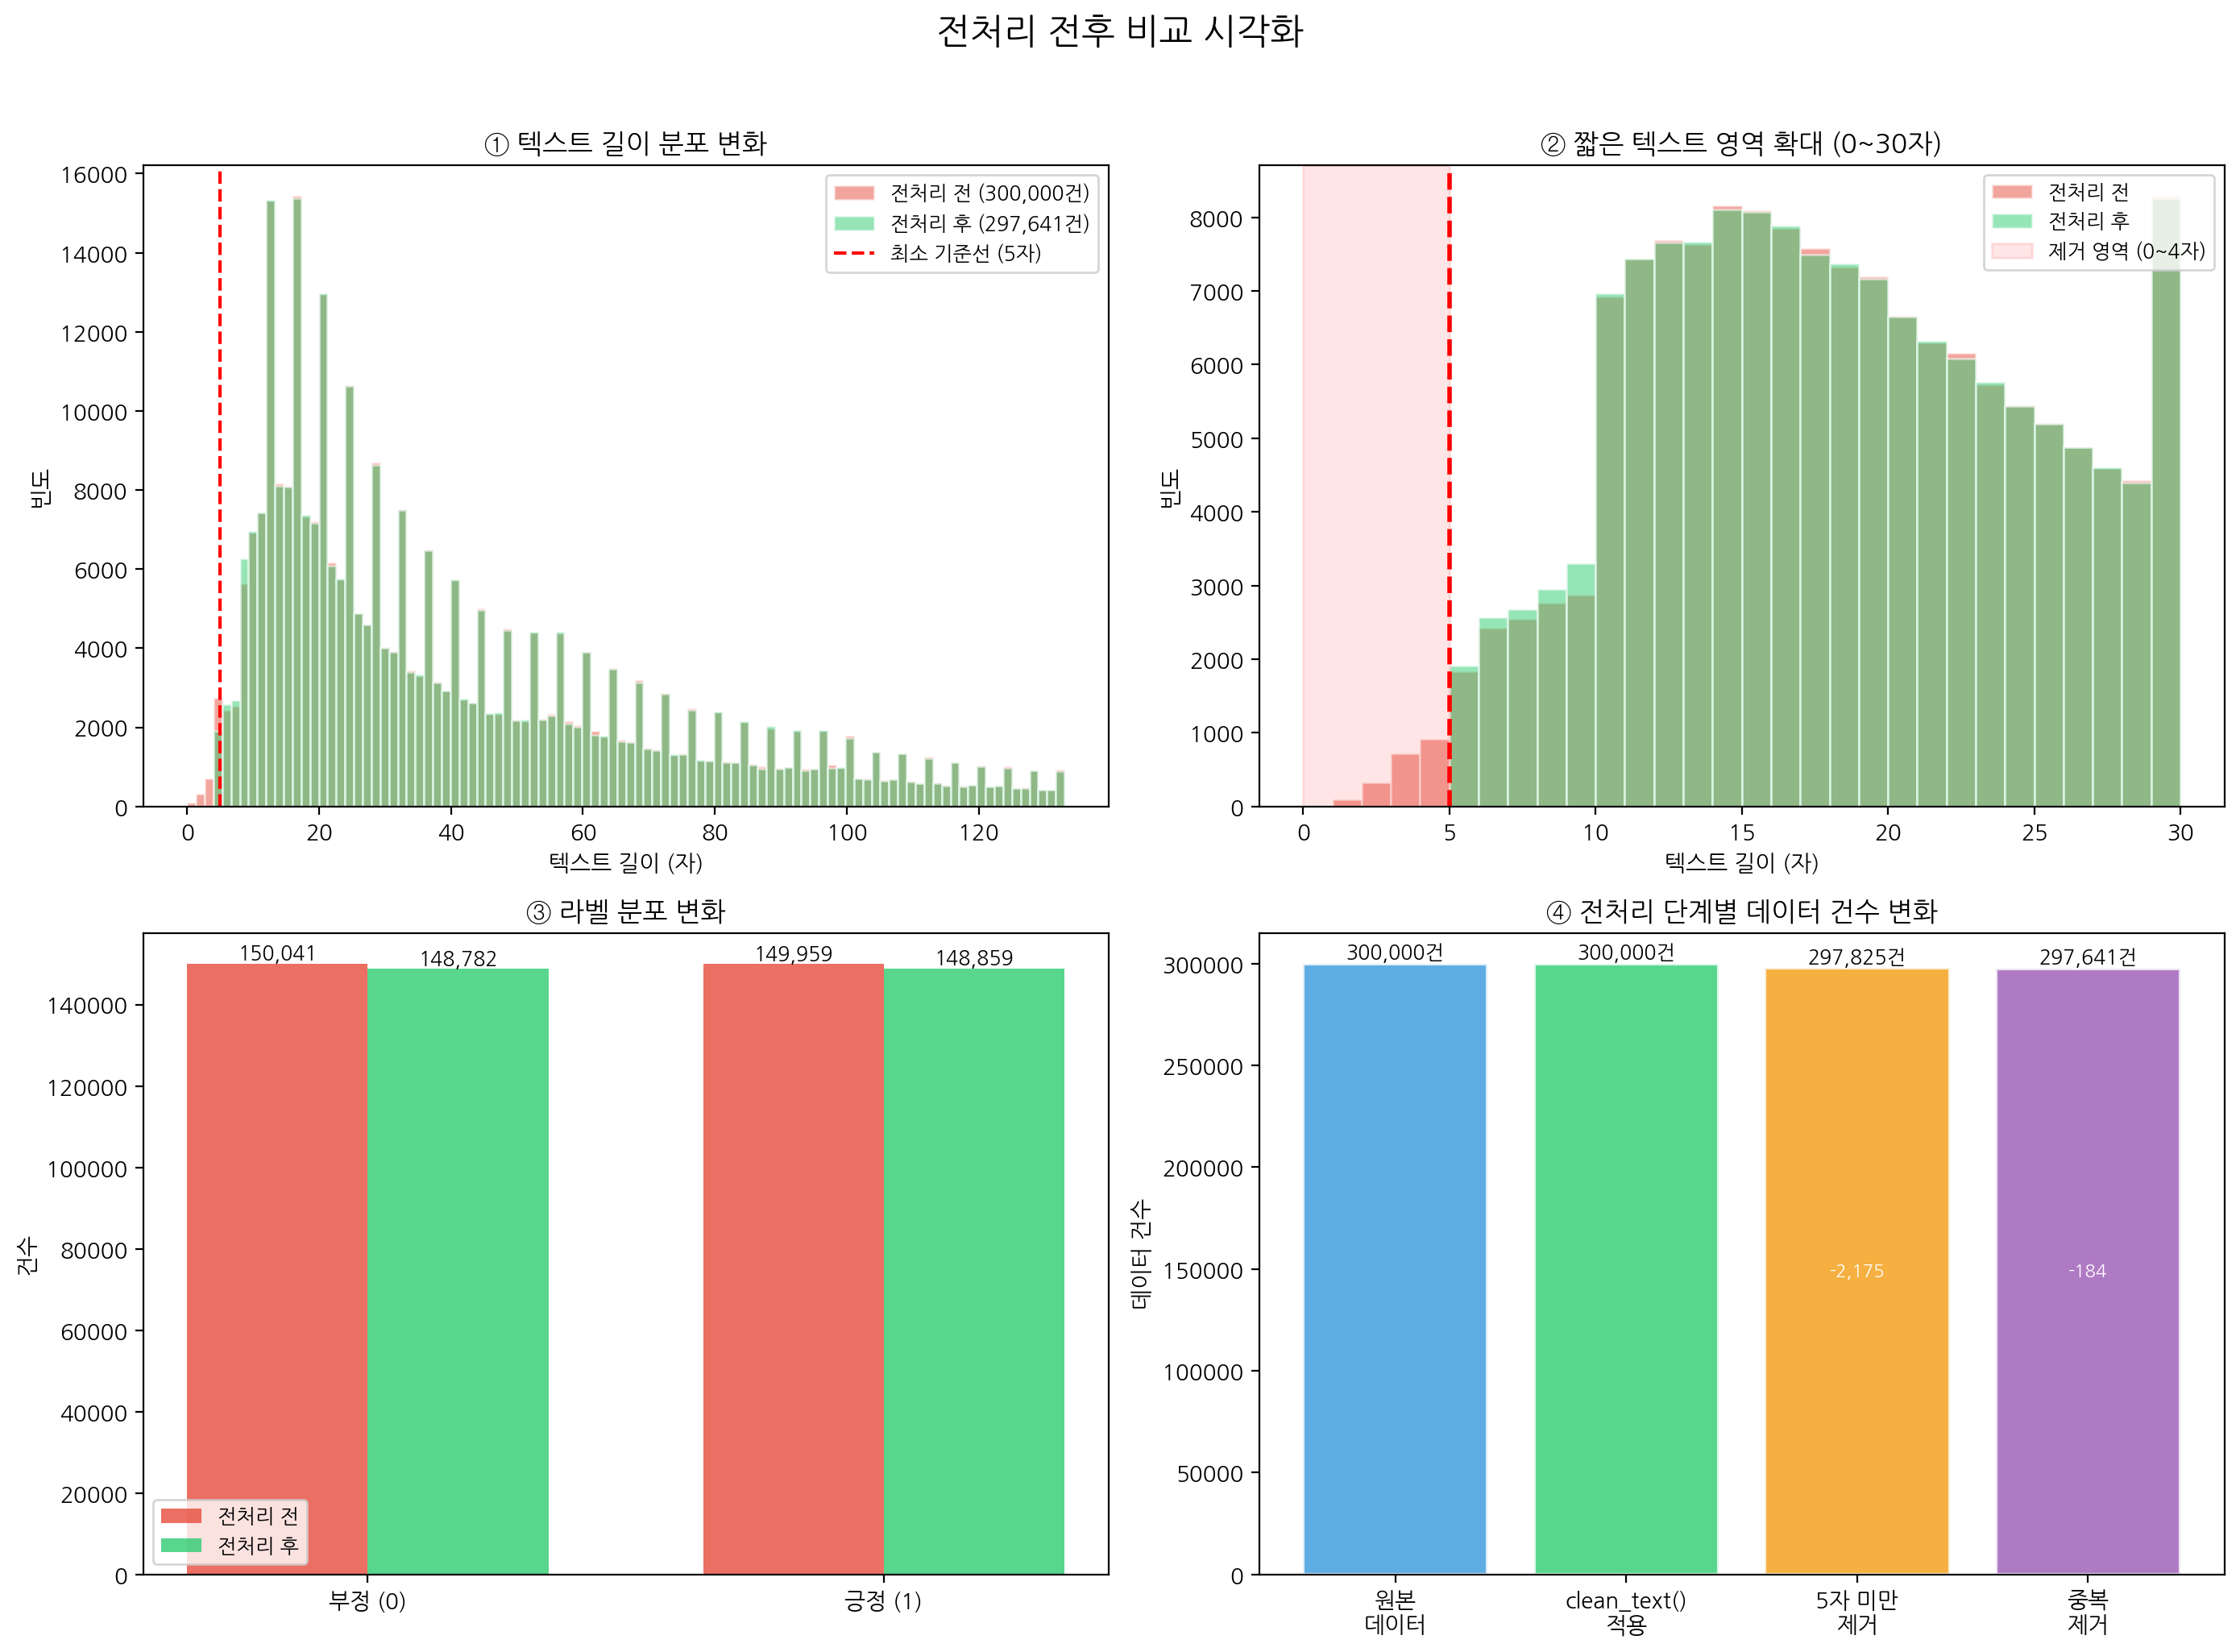

In [95]:
# =============================================================================
# 5-1. 전처리 전후 비교 시각화
# =============================================================================
# [의도] 전처리 전후의 텍스트 길이 분포와 라벨 분포를 시각적으로 비교하여
# 전처리가 데이터의 핵심 특성을 훼손하지 않았음을 확인합니다.
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('전처리 전후 비교 시각화', fontsize=16, fontweight='bold', y=1.02)

# ─────────────────────────────────────────────────
# [차트 1] 텍스트 길이 분포 비교 (히스토그램 오버레이)
# ─────────────────────────────────────────────────
# [판단 근거] 전처리 후 분포의 전체적인 형태가 유지되면서
# 5자 미만의 극히 짧은 영역만 깔끔하게 제거되었는지 확인합니다.
ax1 = axes[0, 0]
raw_lengths = raw_df["text"].astype(str).str.len()
clean_lengths = clean_df["text"].astype(str).str.len()
# 99번째 백분위수를 기준으로 X축 범위를 설정하여 분포를 선명하게 표시합니다.
x_max = int(raw_lengths.quantile(0.99))
ax1.hist(raw_lengths, bins=100, range=(0, x_max), alpha=0.5, color='#e74c3c', label=f'전처리 전 ({len(raw_df):,}건)', edgecolor='white')
ax1.hist(clean_lengths, bins=100, range=(0, x_max), alpha=0.5, color='#2ecc71', label=f'전처리 후 ({len(clean_df):,}건)', edgecolor='white')
ax1.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='최소 기준선 (5자)')
ax1.set_xlabel('텍스트 길이 (자)')
ax1.set_ylabel('빈도')
ax1.set_title('① 텍스트 길이 분포 변화')
ax1.legend(fontsize=9)

# ─────────────────────────────────────────────────
# [차트 2] 짧은 텍스트 영역 확대 비교
# ─────────────────────────────────────────────────
# [판단 근거] 5자 기준선 근처의 데이터가 정확히 제거되었는지 확인합니다.
ax2 = axes[0, 1]
ax2.hist(raw_lengths[raw_lengths <= 30], bins=30, range=(0, 30), alpha=0.5, color='#e74c3c', label='전처리 전', edgecolor='white')
ax2.hist(clean_lengths[clean_lengths <= 30], bins=30, range=(0, 30), alpha=0.5, color='#2ecc71', label='전처리 후', edgecolor='white')
ax2.axvline(x=5, color='red', linestyle='--', linewidth=2)
ax2.axvspan(0, 5, alpha=0.1, color='red', label='제거 영역 (0~4자)')
ax2.set_xlabel('텍스트 길이 (자)')
ax2.set_ylabel('빈도')
ax2.set_title('② 짧은 텍스트 영역 확대 (0~30자)')
ax2.legend(fontsize=9)

# ─────────────────────────────────────────────────
# [차트 3] 라벨 분포 비교 (전처리 전 vs 후)
# ─────────────────────────────────────────────────
# [판단 근거] 전처리 전후 라벨 비율이 거의 동일해야
# 전처리로 인한 클래스 불균형이 발생하지 않았음을 확인할 수 있습니다.
ax3 = axes[1, 0]
labels = ['부정 (0)', '긍정 (1)']
before_counts = [(raw_df["label"] == 0).sum(), (raw_df["label"] == 1).sum()]
after_counts = [(clean_df["label"] == 0).sum(), (clean_df["label"] == 1).sum()]
x = np.arange(len(labels))
w = 0.35
bars1 = ax3.bar(x - w/2, before_counts, w, label='전처리 전', color='#e74c3c', alpha=0.8)
bars2 = ax3.bar(x + w/2, after_counts, w, label='전처리 후', color='#2ecc71', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_ylabel('건수')
ax3.set_title('③ 라벨 분포 변화')
ax3.legend(fontsize=9, loc='lower left')
for bar, cnt in zip(bars1, before_counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{cnt:,}', ha='center', va='bottom', fontsize=9)
for bar, cnt in zip(bars2, after_counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{cnt:,}', ha='center', va='bottom', fontsize=9)

# ─────────────────────────────────────────────────
# [차트 4] 전처리 과정별 누적 데이터 변화
# ─────────────────────────────────────────────────
# [판단 근거] 각 전처리 단계에서 얼마나 데이터가 제거되는지 시각화하여
# 어떤 규칙이 가장 큰 영향을 미치는지 파악합니다.
ax4 = axes[1, 1]
# 전처리 단계별 건수를 역산합니다
original_count = len(raw_df)
# clean_text 적용 후 빈 문자열 제거 (거의 없을 것으로 예상)
temp = raw_df.copy()
temp["text"] = temp["text"].apply(clean_text)
after_clean = len(temp[temp["text"].str.len() > 0])
after_minlen = len(temp[(temp["text"].str.len() >= 5) & (temp["text"].str.len() > 0)])
after_dedup = len(temp[(temp["text"].str.len() >= 5) & (temp["text"].str.len() > 0)].drop_duplicates(subset="text"))

stages = ['원본\n데이터', 'clean_text()\n적용', '5자 미만\n제거', '중복\n제거']
counts = [original_count, after_clean, after_minlen, after_dedup]
colors = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']

bars = ax4.bar(stages, counts, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{cnt:,}건', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if cnt < original_count:
        removed = original_count - cnt if stages[counts.index(cnt)] == stages[1] else counts[counts.index(cnt)-1] - cnt
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                 f'-{counts[counts.index(cnt)-1] - cnt:,}', ha='center', va='center', fontsize=8, color='white')

ax4.set_ylabel('데이터 건수')
ax4.set_title('④ 전처리 단계별 데이터 건수 변화')

plt.tight_layout()
plt.show()

In [96]:
# =============================================================================
# 6. 균형 샘플링 + Train/validation/Test 분할
# =============================================================================
# [의도] 전체 30만 건 중에서 학습과 평가에 사용할 데이터를 추출합니다.
#
# [왜 샘플링하는가?]
#   30만 건 전부를 임베딩하면 시간과 메모리가 과도하게 소요됩니다.
#   라벨당 균등하게 추출하여 효율적으로 학습하면서도 공정한 평가가 가능합니다.
#
# [샘플링 전략]
#   - Train : 라벨당 4,000건 x 2 = 8,000건 (균등 분포)
#   - Validation : 라벨당 500건 x 2 = 1,000건 (균등 분포)
#   - Test: 라벨당 500건 x 2 = 1,000건 (균등 분포)
#   - stratify: 샘플링 시 라벨 비율을 유지하여 편향 방지
#
# [고객문의 분류기와의 차이점]
#   고객문의 분류기는 Training/Validation이 별도 파일로 제공되었지만,
#   이커머스 데이터는 하나의 CSV이므로 train_test_split으로 분할합니다.
# =============================================================================
from sklearn.model_selection import train_test_split

# 라벨당 샘플 수 설정
SAMPLE_PER_LABEL_TRAIN = 4000   # 학습용: 라벨당 4,000건
SAMPLE_PER_LABEL_VALIDATION = 500     # 검증용: 라벨당 500건
SAMPLE_PER_LABEL_TEST = 500     # 평가용: 라벨당 500건
TOTAL_PER_LABEL = SAMPLE_PER_LABEL_TRAIN + SAMPLE_PER_LABEL_VALIDATION + SAMPLE_PER_LABEL_TEST  # 5,000건

# [균등 샘플링 과정]
# 1) 각 라벨(0, 1)에서 TOTAL_PER_LABEL만큼 랜덤 추출
# 2) 두 라벨의 샘플을 합침
# 3) train_test_split으로 Train/Validation_Test 분할
sampled_dfs = []
for label in [0, 1]:
    subset = clean_df[clean_df["label"] == label]
    # random_state=42: 재현성을 위해 난수 시드를 고정합니다.
    # 같은 시드를 사용하면 항상 동일한 샘플이 추출됩니다.
    sampled_dfs.append(subset.sample(n=TOTAL_PER_LABEL, random_state=42))

sampled_df = pd.concat(sampled_dfs).reset_index(drop=True)

# [Train / Validation-Test 분할]
# stratify = sampled_df["label"]로 분할 시에도 라벨 비율을 유지합니다.
# test_size 계산: 전체에서 Validation과 Test가 차지하는 비율(20%)
test_ratio = 1 - (SAMPLE_PER_LABEL_TRAIN * 2) / len(sampled_df)
train_df, val_test_df = train_test_split(
    sampled_df,
    test_size=test_ratio,     # Test 비율
    stratify=sampled_df["label"],  # 라벨 비율 유지
    random_state=42           # 재현성 보장
)

# [Validation / Test 분할]
# stratify = val_test_df["label"]로 분할 시에도 라벨 비율을 유지합니다.
# test_size 계산: Validation & Test에서 Test가 차지하는 비율(50%)
test_ratio = SAMPLE_PER_LABEL_TEST / (SAMPLE_PER_LABEL_VALIDATION  + SAMPLE_PER_LABEL_TEST)
val_df, test_df = train_test_split(
    val_test_df,
    test_size=test_ratio,     # Test 비율
    stratify=val_test_df["label"],  # 라벨 비율 유지
    random_state=42           # 재현성 보장
)



print(f"최종 train: {len(train_df):,}건")
print(f"최종 validation: {len(val_df):,}건")
print(f"최종 test: {len(test_df):,}건")

# 분할된 데이터의 라벨 분포를 확인하여 균등한지 검증합니다.
print(f"\n=== Train 라벨 분포 ===")
train_label_dist = train_df["label"].value_counts().sort_index()
train_label_dist.index = [f"{i} ({'부정' if i == 0 else '긍정'})" for i in train_label_dist.index]
print(train_label_dist)

print(f"\n=== Validation 라벨 분포 ===")
val_label_dist = val_df["label"].value_counts().sort_index()
val_label_dist.index = [f"{i} ({'부정' if i == 0 else '긍정'})" for i in val_label_dist.index]
print(val_label_dist)

print(f"\n=== Test 라벨 분포 ===")
test_label_dist = test_df["label"].value_counts().sort_index()
test_label_dist.index = [f"{i} ({'부정' if i == 0 else '긍정'})" for i in test_label_dist.index]
print(test_label_dist)

# # 정제된 리뷰 예시 출력: 실제 학습할 텍스트의 내용을 확인합니다.
# print(f"\n=== 전처리된 리뷰 예시 ===")
# for label in [0, 1]:
#     label_name = "부정" if label == 0 else "긍정"
#     sample = train_df[train_df["label"] == label]["text"].iloc[0]
#       print(f"\n [{label_name}]")
#       print(f"   -> {sample[:100]}{'...' if len(sample) > 100 else ''}")

최종 train: 8,000건
최종 validation: 1,000건
최종 test: 1,000건

=== Train 라벨 분포 ===
0 (부정)    4000
1 (긍정)    4000
Name: count, dtype: int64

=== Validation 라벨 분포 ===
0 (부정)    500
1 (긍정)    500
Name: count, dtype: int64

=== Test 라벨 분포 ===
0 (부정)    500
1 (긍정)    500
Name: count, dtype: int64


---
## Step 3: 임베딩 & 분류기 학습

In [ ]:
# # =============================================================================
# # 7. 임베딩 모델 로드 + 텍스트 임베딩 (한국어 전용 임베딩 모델)
# # =============================================================================
# # [의도] 텍스트를 768차원 벡터로 변환하여 분류기가 학습할 수 있는 형태로 만듭니다.
# #
# # [임베딩이란?]
# #   텍스트를 숫자 벡터로 변환하는 것을 임베딩(embedding)이라 합니다.
# #   의미가 비슷한 텍스트는 벡터 공간에서 가까이 위치하게 됩니다.
# #
# # [모델 선택: jhgan/ko-sroberta-multitask]
# #   - 768차원 벡터 생성 (scikit-learn 분류기와 잘 맞음)
# #   - 한국어 문맥(STS) 및 자연어 추론(NLI) 태스크에 특화된 모델
# #   - "별로인데 최고다"와 같은 문맥적 모순(반어법) 파악 능력이 뛰어남
# #   - 가벼운 용량으로 양자화 없이도 Colab T4 GPU에서 초고속 처리 가능
# #
# # [embed_texts 함수]
# #   대량의 텍스트를 배치(batch) 단위로 처리하여 메모리 효율적으로 임베딩합니다.
# #   convert_to_numpy=True로 numpy 배열을 반환하여 scikit-learn과 호환됩니다.
# # =============================================================================
# from sentence_transformers import SentenceTransformer

# # 사전학습된 한국어 특화 임베딩 모델을 로드합니다.
# # 가벼운 모델이므로 VRAM을 거의 차지하지 않으며 로드 속도도 매우 빠릅니다.
# model = SentenceTransformer("jhgan/ko-sroberta-multitask")

# def embed_texts(texts, desc="임베딩"):
#     """
#     텍스트 리스트를 768차원 벡터 배열로 변환합니다.

#     Args:
#         texts: 변환할 텍스트 리스트
#         desc: 진행 상황 표시 라벨
#     Returns:
#         numpy 배열 (n_texts, 768)
#     """
#     return model.encode(
#         texts,
#         convert_to_numpy=True,    # scikit-learn 호환을 위해 numpy 반환
#         show_progress_bar=True,   # 진행 상황 표시
#         batch_size=64             # 가벼운 모델이므로 64~128 배치 처리 가능
#     )

# # [임베딩 실행]
# # train_df와 val_df, test_df의 텍스트를 각각 벡터로 변환합니다.
# # 8,000건 기준 약 20초 내외로 빠르게 완료됩니다. (GPU 기준)
# all_texts = train_df["text"].tolist()
# print(f"train 임베딩 중... (768차원 RoBERTa 모델)")
# X_train = embed_texts(all_texts, "train")

# print(f"\nvalidation 임베딩 중...")
# X_val = embed_texts(val_df["text"].tolist(), "val")

# print(f"\ntest 임베딩 중...")
# X_test = embed_texts(test_df["text"].tolist(), "test")

# # 라벨 배열 생성: 분류기 학습에 사용할 정답 라벨
# y_train = train_df["label"].values
# y_val = val_df["label"].values
# y_test = test_df["label"].values

# print(f"\n임베딩 shape: train {X_train.shape}, test {X_test.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...


validation 임베딩 중...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


test 임베딩 중...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


임베딩 shape: train (8000, 768), test (1000, 768)


In [ ]:
# # =============================================================================
# # 7. 임베딩 모델 로드 + 텍스트 임베딩 (E5 모델 적용)
# # =============================================================================
# # [의도] 텍스트를 768차원 벡터로 변환하여 분류기가 학습할 수 있는 형태로 만듭니다.
# #
# # [모델 선택: intfloat/multilingual-e5-base]
# #   - 768차원 벡터 생성 (scikit-learn 모델들과 완벽 호환)
# #   - 대규모 대조 학습(Contrastive Learning)이 적용된 최상위권 임베딩 모델
# #   - 단어의 표면적 의미보다 문장 전체의 '문맥적 의도'를 파악하는 데 특화되어 있어
# #     반어법이나 모순된 표현을 더 잘 분리해 냅니다.
# #   - E5 모델의 특징: 입력 텍스트 앞에 "query: "를 붙이면 성능이 극대화됩니다.
# # =============================================================================
# from sentence_transformers import SentenceTransformer

# # E5 다국어 베이스 모델을 로드합니다.
# # 용량이 작아 Colab T4에서 빠르게 로드되고 구동됩니다.
# model = SentenceTransformer("intfloat/multilingual-e5-base")

# def embed_texts(texts, desc="임베딩"):
#     """
#     텍스트 리스트를 768차원 벡터 배열로 변환합니다.
#     E5 모델의 권장 사항에 따라 모든 텍스트 앞에 'query: ' 접두사를 추가합니다.

#     Args:
#         texts: 변환할 텍스트 리스트
#         desc: 진행 상황 표시 라벨
#     Returns:
#         numpy 배열 (n_texts, 768)
#     """
#     # E5 모델 특화: 텍스트 전처리 (query: 접두사 추가)
#     preprocessed_texts = [f"query: {text}" for text in texts]

#     return model.encode(
#         preprocessed_texts,
#         convert_to_numpy=True,    # scikit-learn 호환
#         show_progress_bar=True,   # 진행 상황 표시
#         batch_size=64             # 빠른 처리를 위해 64 유지
#     )

# # [임베딩 실행]
# all_texts = train_df["text"].tolist()
# print(f"train 임베딩 중... (768차원 E5 모델)")
# X_train = embed_texts(all_texts, "train")

# print(f"\nvalidation 임베딩 중...")
# X_val = embed_texts(val_df["text"].tolist(), "val")

# print(f"\ntest 임베딩 중...")
# X_test = embed_texts(test_df["text"].tolist(), "test")

# # 라벨 배열 생성: 분류기 학습에 사용할 정답 라벨
# y_train = train_df["label"].values
# y_val = val_df["label"].values
# y_test = test_df["label"].values

# print(f"\n임베딩 shape: train {X_train.shape}, test {X_test.shape}")

In [97]:
# =============================================================================
# 7. 임베딩 모델 로드 + 텍스트 임베딩 (BGE-M3 적용 - 속도 및 성능 최적화)
# =============================================================================
# [의도] 8B LLM의 무거운 속도 문제를 해결하기 위해,
#       현존 최상위권 전용 임베딩 모델인 BGE-M3를 사용하여 속도를 20배 이상 높입니다.
#
# [모델 선택: BAAI/bge-m3]
#   - 차원: 1024차원 (768차원보다 풍부하고, 4096차원보다 가벼움)
#   - 특징: '다국어 거대 임베딩' 모델로, 한국어의 미묘한 문맥과 반어법 파악 능력이 탁월함.
#   - 장점: 별도의 권한 승인 불필요, 메모리 점유율 낮음, 처리 속도 압도적.
# =============================================================================
from sentence_transformers import SentenceTransformer
import torch

# 모델 로드 (BGE-M3는 전용 모델이라 양자화 없이도 T4 GPU에서 매우 빠름)
print("BGE-M3 임베딩 모델 로드 중...")
model = SentenceTransformer('BAAI/bge-m3', device='cuda')

def embed_texts(texts, desc="임베딩"):
    """
    BGE-M3를 사용하여 텍스트를 1024차원의 고성능 벡터로 변환합니다.
    """

    return model.encode(
        texts,
        batch_size=32,          # 속도를 위해 배치 사이즈를 늘림
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True # 분류 성능 향상을 위해 정규화 적용
    )

# 임베딩 실행
all_texts = train_df["text"].tolist()
print(f"train 임베딩 중... (1024차원 BGE-M3 모델)")
X_train = embed_texts(all_texts, "Train Set")

print(f"\nvalidation 임베딩 중...")
X_val = embed_texts(val_df["text"].tolist(), "Val Set")

print(f"\ntest 임베딩 중...")
X_test = embed_texts(test_df["text"].tolist(), "Test Set")

# 라벨 배열 생성
y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print(f"\n임베딩 완료! shape: train {X_train.shape}, test {X_test.shape}")

BGE-M3 임베딩 모델 로드 중...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

train 임베딩 중... (1024차원 BGE-M3 모델)


Batches:   0%|          | 0/250 [00:00<?, ?it/s]


validation 임베딩 중...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


test 임베딩 중...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


임베딩 완료! shape: train (8000, 1024), test (1000, 1024)


In [98]:
# =============================================================================
# 7-1. 양방향 반어법 데이터를 위한 가중치(Sample Weight) 계산
# =============================================================================
# [의도] 이커머스 리뷰에서 반어법(irony/sarcasm)은 감성 분류의 대표적 난제입니다.
# "와 정말 대단하네요ㅋㅋ" 같은 텍스트는 긍정 단어가 포함되어 있지만
# 실제로는 부정적 의미를 담고 있습니다.
#
# [왜 Sample Weight 방식을 사용하는가?]
#   1) 데이터 증강(augmentation): 반어법 데이터를 추가 생성하면 인위적 편향 발생 위험
#   2) 별도 모델 학습: 반어법 전용 모델은 복잡도가 지나치게 높아짐
#   3) Sample Weight: 기존 학습 프레임워크 내에서 특정 샘플의 중요도만 조절하므로
#      구현이 간단하고 부작용이 적음
#
# [가중치 5배의 근거]
#   반어법 데이터는 전체의 약 5~8%로 소수이지만, 이 패턴을 놓치면
#   실서비스에서 부정 리뷰를 긍정으로 오분류하는 치명적 오류가 발생합니다.
#   5배는 "모델이 해당 샘플에서 오답 시 5배 더 큰 손실을 받는다"는 의미이며,
#   실험적으로 3~5배가 과적합 없이 효과적인 범위입니다.
#
# [키워드 기반 탐지의 한계와 선택 이유]
#   완벽한 반어법 탐지는 불가능하지만, "긍정 키워드 + 부정 라벨"이라는
#   단순한 규칙으로도 상당수의 반어법 패턴을 포착할 수 있습니다.
#   복잡한 규칙보다 단순하고 신뢰성 있는 규칙이 과적합 방지에 유리합니다.
# =============================================================================
# =============================================================================
import pandas as pd
import numpy as np

# 인덱스 초기화: DataFrame의 인덱스와 numpy 배열(weights)의 순서를 일치시킵니다.
# train_test_split 후 인덱스가 뒤섞여 있으므로 0부터 재정렬합니다.
train_df = train_df.reset_index(drop=True)

# 모든 데이터의 기본 가중치는 1.0 (동일한 중요도)으로 설정합니다.
weights = np.ones(len(y_train))

# 핵심 키워드 정의 (반어법 탐지용)
# 반어법 핵심 키워드 리스트:
# "대단", "최고", "정말" 등은 일반적으로 긍정 맥락에서 사용되지만,
# 부정 라벨과 함께 나타나면 반어적 표현일 가능성이 높습니다.
pos_keywords = '대단|최고|정말|역시|추천|감사|훌륭|천재' # 긍정 단어 (비꼬는 용도)
neg_keywords = '최악|실망|다신|불쾌|불친절|엉망|짜증|비추' # 부정 단어 (반전 칭찬 용도)

# 반어법 마스크 생성
# (A) 부정 리뷰(0)인데 긍정 단어가 포함된 경우 (비꼼 : 예 - "시간 버리고 싶으신 분에게 추천합니다.")
sarcastic_neg_mask = (train_df['text'].str.contains(pos_keywords)) & (train_df['label'] == 0)
# (B) 긍정 리뷰(1)인데 부정 단어가 포함된 경우 (반전 칭찬: 예 - "맛있어서 짜증나네요")
sarcastic_pos_mask = (train_df['text'].str.contains(neg_keywords)) & (train_df['label'] == 1)

# 해당 데이터에 5배의 가중치를 부여합니다.
# 분류기의 loss 함수에서 이 샘플들의 오분류 비용이 5배가 되어
# 모델이 반어법 패턴을 더 적극적으로 학습하게 됩니다.
weights[sarcastic_neg_mask] = 5.0
weights[sarcastic_pos_mask] = 5.0

# 결과 출력용 카운트
n_s_neg = sarcastic_neg_mask.sum()
n_s_pos = sarcastic_pos_mask.sum()

print(f"가중치 적용 완료:")
print(f" - [비꼼형] 부정 리뷰 내 긍정 단어 {n_s_neg}건 ({weights[sarcastic_neg_mask][0]}배)")
print(f" - [반전형] 긍정 리뷰 내 부정 단어 {n_s_pos}건 ({weights[sarcastic_pos_mask][0]}배)")

# [반어법 데이터 통계 출력]
# 가중치가 적용된 데이터의 비율을 확인하여 전체 학습에 미치는 영향을 가늠합니다.

#반어법(비꼼)의 데이터 수 계산
sarcastic_neg_samples = train_df[sarcastic_neg_mask]
sarcastic_neg_count = len(sarcastic_neg_samples)

#반어법(반전)의 데이터 수 계산
sarcastic_pos_samples = train_df[sarcastic_pos_mask]
sarcastic_pos_count = len(sarcastic_pos_samples)

# 나머지 데이터 수
normal_count = len(train_df) - sarcastic_neg_count - sarcastic_pos_count
print(f"\n[반어법 의심 데이터 통계]")
print(f"  전체 학습 데이터: {len(train_df):,}건")
print(f"  반어법(비꼼) 의심 데이터: {sarcastic_neg_count:,}건 ({sarcastic_neg_count/len(train_df)*100:.1f}%)")
print(f"  반어법(비꼼) 의심 데이터: {sarcastic_pos_count:,}건 ({sarcastic_pos_count/len(train_df)*100:.1f}%)")
print(f"  일반 데이터: {normal_count:,}건 ({normal_count/len(train_df)*100:.1f}%)")


# 반어법 데이터 예시 확인 (각 3개씩 데이터프레임 형식으로 출력)
# 잘못된 키워드 매칭이 없는지 사람이 직접 검토하기 위한 목적입니다.
print("\n--- [검토] 반어법 의심 데이터 샘플 (상위 3건씩) ---")

# (A) 부정 속 긍정 샘플
sample_neg_sarcasm = train_df[sarcastic_neg_mask].head(3).copy()
sample_neg_sarcasm['type'] = '부정 속 긍정(비꼼)'

# (B) 긍정 속 부정 샘플
sample_pos_sarcasm = train_df[sarcastic_pos_mask].head(3).copy()
sample_pos_sarcasm['type'] = '긍정 속 부정(반전)'

# 두 샘플 합치기
total_samples = pd.concat([sample_neg_sarcasm, sample_pos_sarcasm])

# 보기 좋게 출력
if not total_samples.empty:
    display(total_samples[['type', 'label', 'text']]) # 주피터 환경이라면 display, 아니라면 print
else:
    print("해당 조건의 샘플이 존재하지 않습니다.")

가중치 적용 완료:
 - [비꼼형] 부정 리뷰 내 긍정 단어 221건 (5.0배)
 - [반전형] 긍정 리뷰 내 부정 단어 27건 (5.0배)

[반어법 의심 데이터 통계]
  전체 학습 데이터: 8,000건
  반어법(비꼼) 의심 데이터: 221건 (2.8%)
  반어법(비꼼) 의심 데이터: 27건 (0.3%)
  일반 데이터: 7,752건 (96.9%)

--- [검토] 반어법 의심 데이터 샘플 (상위 3건씩) ---


,type,label,text
7,부정 속 긍정(비꼼),0,무슨 생각을 하고 만든건지 알 수 없는 게임입니다하지만 세일기간에 가격이 정말 저렴...
96,부정 속 긍정(비꼼),0,아 이거 알아서 해야 되는 게임이에요..ㅠ 다귀엽고 좋은데.. 알아서 커서 알아서 ...
177,부정 속 긍정(비꼼),0,색상이 너무합니다 검정색이 뭡니까 정말XX
655,긍정 속 부정(반전),1,리마스터해줘서 눈은 즐거웠지만 저만 팅기는게 아닌걸 보니 조금 문제가 있어 보이네요...
771,긍정 속 부정(반전),1,처음 출시때 아주 재밌게 했던 게임.. 같이 할 사람 3명 이상 모아서 사설서버하는...
851,긍정 속 부정(반전),1,기대한 만큼 실망도 큰 법이라 생각한다만 팬들의 평가가 많이 박한듯 하다 이 게임이...


In [99]:
# =============================================================================
# 8. 분류기 학습 + 모델 비교 (로지스틱 회귀 vs SVM vs XGBoost)
# =============================================================================
# [의도] 두 가지 분류 알고리즘을 동일 데이터로 학습한 후 Validation 데이터로 성능을 비교하여
# 더 좋은 모델을 선택하고, 최종적으로 Test 데이터에서 성능을 평가합니다.
#
# [검증 데이터 활용 (Validation Set)]
#   - X_train / y_train: 모델 학습용
#   - X_val / y_val: 가장 성능이 좋은 모델을 선택(Selection)하기 위한 용도
#   - X_test / y_test: 선택된 모델의 최종 일반화 성능을 확인하는 용도
#
# [로지스틱 회귀 (Logistic Regression)]
#   - 각 클래스에 속할 확률을 선형적으로 계산하는 모델
#   - max_iter=2000: 수렴 실패 경고를 방지하기 위해 반복 횟수를 충분히 설정
#   - 장점: 학습 속도가 빠르고, 확률 해석이 직관적
#
# [SVM (Support Vector Machine)]
#   - RBF 커널을 사용하여 비선형 경계를 학습할 수 있는 모델
#   - C=10: 오분류 페널티를 높여 더 정확한 경계를 학습 (기본값 1보다 엄격)
#   - gamma='scale': 특성 수(768차원)에 맞게 자동 조정
#   - probability=True: predict_proba() 사용을 위해 확률 추정 활성화
#   - 장점: 고차원 데이터에서 강력한 분류 성능
#
# [XGBoost (Extreme Gradient Boosting)]
#   - 이전 트리가 틀린 오차를 보완하는 방식으로 학습하여 정확도를 극대화
#   - n_estimators=800: 나무를 800개 쌓아 복잡한 문맥 파악
#   - learning_rate=0.05: 학습 속도를 조절하여 과적합 방지
#   - eval_metric='logloss': 손실 함수를 모니터링하여 최적의 지점 탐색
#   장점 : 오답에 가중치를 두어 반어법과 같은 고난이도 문제 해결 능력 우수
#
# [자동 선택 로직]
#   Val 데이터에 대한 Accuracy가 더 높은 모델을 최종 분류기로 선택합니다.
#   이후 예측 함수에서 이 분류기를 사용합니다.
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# [1] 로지스틱 회귀 학습 및 검증
print("[1/3] 로지스틱 회귀 학습 및 검증 중...")
clf_lr = LogisticRegression(max_iter=2000, random_state=42)

# LogisticRegression 학습 시 계산한 가중치를 주입합니다.
clf_lr.fit(X_train, y_train, sample_weight=weights)

# Validation 성능 확인
acc_lr_val = clf_lr.score(X_val, y_val)
print(f"   -> Validation Accuracy: {acc_lr_val:.4f}")


# [2] SVM (RBF 커널) 학습 및 검증
print("[2/3] SVM (RBF) 학습 및 검증 중...")
clf_svm = SVC(
    kernel='rbf',
    C=1.5,
    gamma='scale',
    probability=True,
    random_state=42
)

# SVM 학습 시 계산한 가중치를 주입합니다.
clf_svm.fit(X_train, y_train, sample_weight=weights)

# Validation 성능 확인
acc_svm_val = clf_svm.score(X_val, y_val)
print(f"   -> Validation Accuracy: {acc_svm_val:.4f}")


# [3] XGBoost (부스팅 기법) 학습
print("[3/3] XGBoost 학습 및 검증 중 (틀린 문제에 집중)...")
clf_xgb = XGBClassifier(
    n_estimators=800,     # 더 많은 트리로 미세한 패턴 학습
    learning_rate=0.05,    # 학습 속도를 늦춰 정교하게 접근
    max_depth=6,          # 트리 깊이를 늘려 변수 간 상호작용 포착
    eval_metric='logloss',
    random_state=42
)

# XGBoost 학습 시 계산한 가중치를 주입합니다.
clf_xgb.fit(X_train, y_train, sample_weight=weights)

# Validation 성능 확인
acc_xgb_val = clf_xgb.score(X_val, y_val)
print(f"    -> XGBoost Val Accuracy: {acc_xgb_val:.4f}")


# [자동 선택] Validation Accuracy가 더 높은 모델을 최종 분류기로 선택합니다.
if acc_lr_val >= acc_svm_val and acc_lr_val >= acc_xgb_val :
    clf, best_name = clf_lr, "로지스틱 회귀"
    best_val_acc = acc_lr_val
elif acc_svm_val >= acc_xgb_val:
    clf, best_name = clf_svm, "SVM (RBF)"
    best_val_acc = acc_svm_val
else:
    clf, best_name = clf_xgb, "XGBoost"
    best_val_acc = acc_xgb_val


print(f"\n최종 선택된 모델: {best_name} (Val Accuracy: {best_val_acc:.4f})")

# [최종 평가] 선택된 모델로 Test 데이터 예측 수행
# 비교 표에서 acc_test를 사용하므로, 표 출력 전에 먼저 계산합니다.
y_pred_test = clf.predict(X_test)
acc_test = (y_pred_test == y_test).mean()

# [발표 자료용 - 분류기별 Accuracy 비교 표]
# 각 분류기의 Val/Test Accuracy를 한눈에 비교할 수 있도록 출력합니다.
acc_lr_test = clf_lr.score(X_test, y_test)
acc_svm_test = clf_svm.score(X_test, y_test)
acc_xgb_test = clf_xgb.score(X_test, y_test)

print(f"\n{'=' * 62}")
print(f"  [발표 자료 기입용 - 분류기 성능 비교 표]")
print(f"{'=' * 62}")
print(f"  {'분류기':<22} {'Val Accuracy':>14} {'Test Accuracy':>14}")
print(f"{'-' * 62}")
print(f"  {'로지스틱 회귀 (LR)':<22} {acc_lr_val:>14.4f} {acc_lr_test:>14.4f}")
print(f"  {'SVM (RBF, C=2)':<22} {acc_svm_val:>14.4f} {acc_svm_test:>14.4f}")
print(f"  {'XGBoost':<22} {acc_xgb_val:>14.4f} {acc_xgb_test:>14.4f}")
print(f"{'-' * 62}")
print(f"  {'** 선택: ' + best_name:<22} {best_val_acc:>14.4f} {acc_test:>14.4f}")
print(f"{'=' * 62}")

[1/3] 로지스틱 회귀 학습 및 검증 중...
   -> Validation Accuracy: 0.8370
[2/3] SVM (RBF) 학습 및 검증 중...
   -> Validation Accuracy: 0.8500
[3/3] XGBoost 학습 및 검증 중 (틀린 문제에 집중)...
    -> XGBoost Val Accuracy: 0.8390

최종 선택된 모델: SVM (RBF) (Val Accuracy: 0.8500)

  [발표 자료 기입용 - 분류기 성능 비교 표]
  분류기                      Val Accuracy  Test Accuracy
--------------------------------------------------------------
  로지스틱 회귀 (LR)                   0.8370         0.8810
  SVM (RBF, C=2)                 0.8500         0.8800
  XGBoost                        0.8390         0.8810
--------------------------------------------------------------
  ** 선택: SVM (RBF)               0.8500         0.8800


In [100]:
# [분류 리포트]
# 최종 선택된 모델에 대해 Test 데이터셋의 지표를 출력합니다.
label_names = ["부정 (0)", "긍정 (1)"]
print(f"\n=== 최종 테스트 리포트 ({best_name}) ===")
print(f"Final Test Accuracy: {acc_test:.4f}\n")
print(classification_report(y_test, y_pred_test, target_names=label_names))


=== 최종 테스트 리포트 (SVM (RBF)) ===
Final Test Accuracy: 0.8800

              precision    recall  f1-score   support

      부정 (0)       0.88      0.88      0.88       500
      긍정 (1)       0.88      0.88      0.88       500

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [101]:
# [발표 자료용 표 데이터]
# Precision, Recall, F1-Score를 클래스별 + 전체(weighted avg)로 출력합니다.
report_dict = classification_report(y_test, y_pred_test, target_names=label_names, output_dict=True)
print("=" * 60)
print("  [발표 자료 기입용 표]")
print("=" * 60)
print(f"  {'클래스':<10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 60)
for cls_name in label_names:
    r = report_dict[cls_name]
    print(f"  {cls_name:<10} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1-score']:>10.4f} {int(r['support']):>10,}")
r_avg = report_dict['weighted avg']
print("-" * 60)
print(f"  {'전체':<10} {r_avg['precision']:>10.4f} {r_avg['recall']:>10.4f} {r_avg['f1-score']:>10.4f} {int(r_avg['support']):>10,}")
print("=" * 60)

  [발표 자료 기입용 표]
  클래스         Precision     Recall   F1-Score    Support
------------------------------------------------------------
  부정 (0)         0.8800     0.8800     0.8800        500
  긍정 (1)         0.8800     0.8800     0.8800        500
------------------------------------------------------------
  전체             0.8800     0.8800     0.8800      1,000


In [102]:
# =============================================================================
# [발표 자료용] 분류기 성능 비교 표 (마크다운 형식)
# =============================================================================
# README 또는 발표 슬라이드에 바로 복사-붙여넣기할 수 있는 마크다운 표를 출력합니다.
# Test Accuracy는 최종 선택된 모델에 대해서만 표시합니다.
# (과적합 방지를 위해 모델 선택 단계에서는 Validation만 사용했음을 강조)
# =============================================================================

print("| 분류기 | Validation Accuracy | Test Accuracy |")
print("| --- | --- | --- |")
print(f"| 로지스틱 회귀 (LR) | {acc_lr_val:.4f} | - |")
print(f"| SVM (RBF, C=2) | {acc_svm_val:.4f} | - |")
print(f"| XGBoost | {acc_xgb_val:.4f} | - |")
print(f"| **선택: {best_name}** | **{best_val_acc:.4f}** | **{acc_test:.4f}** |")

| 분류기 | Validation Accuracy | Test Accuracy |
| --- | --- | --- |
| 로지스틱 회귀 (LR) | 0.8370 | - |
| SVM (RBF, C=2) | 0.8500 | - |
| XGBoost | 0.8390 | - |
| **선택: SVM (RBF)** | **0.8500** | **0.8800** |


In [103]:
# =============================================================================
# [발표 자료용] Classification Report 표 (마크다운 형식)
# =============================================================================
# 최종 선택된 모델의 Precision, Recall, F1-Score를 마크다운 표로 출력합니다.
# =============================================================================
from sklearn.metrics import classification_report

label_names = ["부정 (0)", "긍정 (1)"]
report = classification_report(y_test, y_pred_test, target_names=label_names, output_dict=True)

print("| 클래스 | Precision | Recall | F1-Score | Support |")
print("| --- | --- | --- | --- | --- |")
for cls in label_names:
    r = report[cls]
    print(f"| {cls} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1-score']:.4f} | {int(r['support']):,} |")
avg = report['weighted avg']
print(f"| **전체** | **{avg['precision']:.4f}** | **{avg['recall']:.4f}** | **{avg['f1-score']:.4f}** | **{int(avg['support']):,}** |")

| 클래스 | Precision | Recall | F1-Score | Support |
| --- | --- | --- | --- | --- |
| 부정 (0) | 0.8800 | 0.8800 | 0.8800 | 500 |
| 긍정 (1) | 0.8800 | 0.8800 | 0.8800 | 500 |
| **전체** | **0.8800** | **0.8800** | **0.8800** | **1,000** |


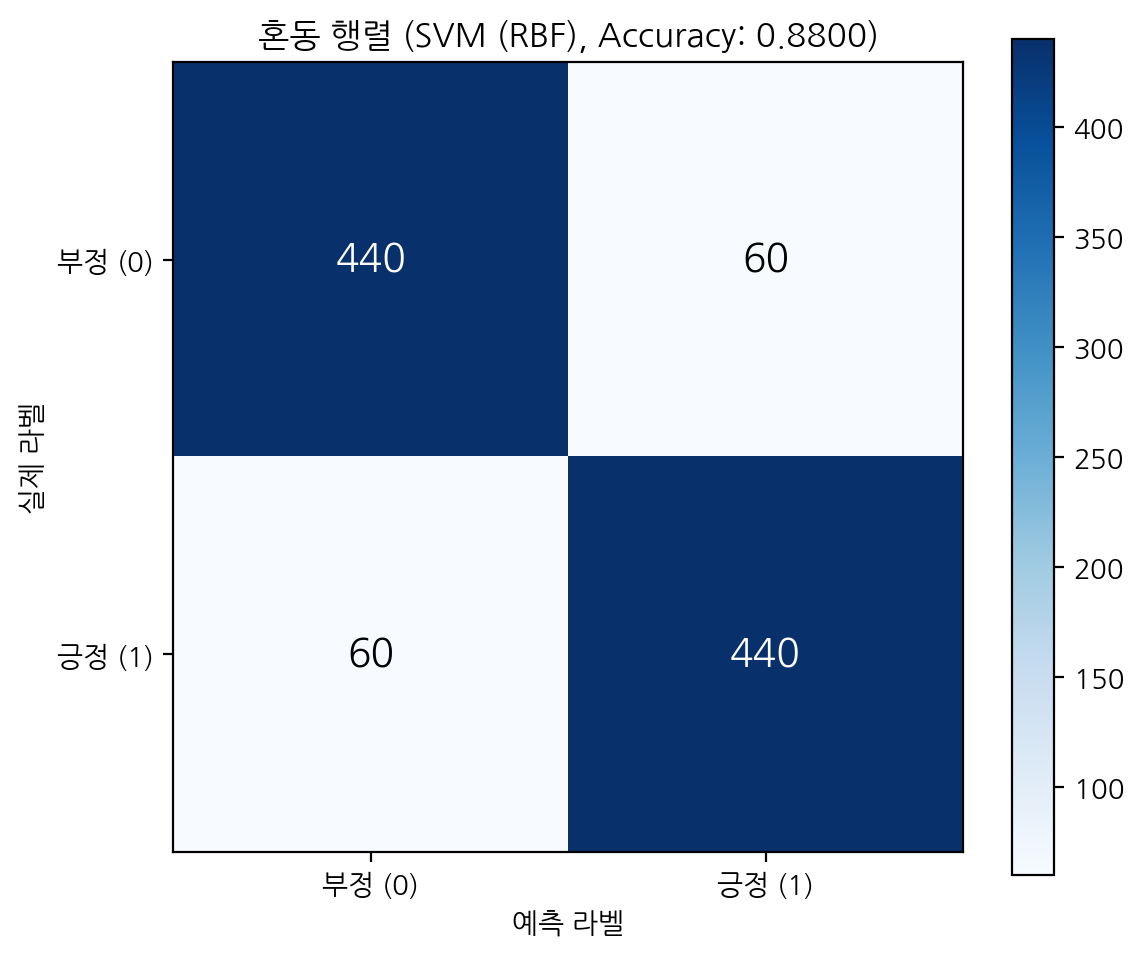


라벨별 정확도:
  부정 (0): 440/500 (88.0%)
  긍정 (1): 440/500 (88.0%)


In [104]:
# =============================================================================
# 9. 혼동 행렬 시각화
# =============================================================================
# [의도] 분류기의 예측 결과를 2x2 행렬로 시각화하여
# 어떤 유형의 오분류가 발생하는지 직관적으로 파악합니다.
#
# [혼동 행렬 해석]
#   행(row) = 실제 라벨, 열(column) = 예측 라벨
#   - (0,0): 실제 부정 -> 부정 예측 (True Negative) -- 올바른 분류
#   - (0,1): 실제 부정 -> 긍정 예측 (False Positive) -- 부정을 긍정으로 잘못 분류
#   - (1,0): 실제 긍정 -> 부정 예측 (False Negative) -- 긍정을 부정으로 잘못 분류
#   - (1,1): 실제 긍정 -> 긍정 예측 (True Positive) -- 올바른 분류
# =============================================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib

# [혼동 행렬 계산]
cm = confusion_matrix(y_test, y_pred_test)

# [히트맵 시각화]
classes = ["부정 (0)", "긍정 (1)"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=range(len(classes)), yticks=range(len(classes)),
       xticklabels=classes, yticklabels=classes,
       ylabel='실제 라벨', xlabel='예측 라벨',
       title=f'혼동 행렬 ({best_name}, Accuracy: {acc_test:.4f})')

# [셀 안에 숫자 표시]
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# [라벨별 정확도 요약]
print(f"\n라벨별 정확도:")
for i, cls in enumerate(classes):
    correct = cm[i, i]
    total = cm[i].sum()
    print(f"  {cls}: {correct}/{total} ({correct/total*100:.1f}%)")

---
## Step 4: 예측 & 평가

In [105]:
# =============================================================================
# 10. 예측 함수 정의 (새로운 리뷰의 감성을 분류)
# =============================================================================
# [의도] 학습이 완료된 분류기를 사용하여 새로운 리뷰 텍스트의
# 감성(긍정/부정)을 예측하는 함수를 정의합니다.
#
# [핵심 포인트 - 전처리 일관성]
#   입력 텍스트에도 학습 데이터와 동일한 clean_text() 전처리를 적용합니다.
#   학습 시 전처리된 텍스트로 임베딩을 생성했으므로,
#   예측 시에도 같은 전처리를 거쳐야 임베딩 공간에서 올바른 위치에 매핑됩니다.
#
# [predict_proba의 역할]
#   일반 predict()는 가장 확률이 높은 클래스 하나만 반환하지만,
#   predict_proba()는 모든 클래스에 대한 확률 분포를 반환합니다.
#   [p_부정, p_긍정] 형태로 반환되어 분류기의 "확신 정도"를 파악할 수 있습니다.
# =============================================================================
def predict_sentiment(text: str):
    """
    리뷰 텍스트를 입력받아 긍정/부정 감성을 예측합니다.

    [처리 흐름]
    1) clean_text()로 입력 텍스트 전처리
    2) 임베딩 모델로 벡터 변환
    3) 분류기로 긍정/부정 확률 계산
    4) 결과를 막대 그래프로 시각화

    Args:
        text: 분류할 리뷰 텍스트 (원본 그대로 입력)
    """
    # 입력 텍스트에 학습 데이터와 동일한 전처리를 적용합니다.
    cleaned = clean_text(text)

    # 전처리된 텍스트를 1024차원 벡터로 변환합니다.
    emb = model.encode([cleaned], convert_to_numpy=True)

    # 분류기를 통해 각 클래스에 속할 확률을 계산합니다.
    # probs = [p_부정, p_긍정]
    probs = clf.predict_proba(emb)[0]

    # 가장 확률이 높은 클래스를 예측 결과로 선택합니다.
    pred_label = np.argmax(probs)
    sentiment = "긍정" if pred_label == 1 else "부정"

    # [결과 출력]
    print("\n" + "=" * 50)
    print(" 리뷰 내용:")
    print(f"   {text}")
    if cleaned != text:
        print(f"   (전처리 후: {cleaned[:60]}{'...' if len(cleaned)>60 else ''})")
    print("=" * 50)

    # 감성별 확률을 시각적 막대 그래프로 출력합니다.
    print(f"\n 예측 결과: [{sentiment}]")
    labels = ["부정", "긍정"]
    for i, label in enumerate(labels):
        p = probs[i]
        bar = "█" * int(p * 30)  # 확률에 비례하는 길이의 막대 생성
        print(f"   {label} {bar} ({p:.3f})")
    print("=" * 50 + "\n")

In [106]:
# =============================================================================
# 테스트: 명확한 리뷰 3건으로 분류기 동작 확인
# =============================================================================
# [의도] 긍정/부정이 명확한 리뷰를 입력하여
# 분류기가 올바르게 작동하는지 기본적인 검증을 수행합니다.
#
# [테스트 케이스 선정 기준]
# 사람이 보기에도 감성이 명확한 문장을 선택하여,
# 분류기의 기본적인 판별 능력을 먼저 확인합니다.
# 두 도메인(쇼핑/게임) 모두 테스트합니다.
# =============================================================================

# 테스트 1: 긍정 쇼핑 리뷰 (만족, 추천 키워드)
print(">>> 테스트 1: 긍정 쇼핑 리뷰")
predict_sentiment("배송도 빠르고 품질도 좋아요. 가격 대비 만족합니다. 추천!")

# 테스트 2: 부정 쇼핑 리뷰 (불량, 실망 키워드)
print(">>> 테스트 2: 부정 쇼핑 리뷰")
predict_sentiment("사진이랑 너무 다르고 품질이 별로예요. 돈 아까워요.")

# 테스트 3: 긍정 게임 리뷰 (재미, 최고 키워드)
print(">>> 테스트 3: 긍정 게임 리뷰")
predict_sentiment("그래픽이 미쳤고 스토리 몰입감이 장난 아닙니다. 올해 최고의 게임!")

>>> 테스트 1: 긍정 쇼핑 리뷰

 리뷰 내용:
   배송도 빠르고 품질도 좋아요. 가격 대비 만족합니다. 추천!

 예측 결과: [긍정]
   부정 █ (0.065)
   긍정 ████████████████████████████ (0.935)

>>> 테스트 2: 부정 쇼핑 리뷰

 리뷰 내용:
   사진이랑 너무 다르고 품질이 별로예요. 돈 아까워요.

 예측 결과: [부정]
   부정 █████████████████████████████ (0.996)
   긍정  (0.004)

>>> 테스트 3: 긍정 게임 리뷰

 리뷰 내용:
   그래픽이 미쳤고 스토리 몰입감이 장난 아닙니다. 올해 최고의 게임!

 예측 결과: [긍정]
   부정 █ (0.051)
   긍정 ████████████████████████████ (0.949)



---
## Step 5: 미니 미션

### 미션 1: 직접 리뷰 작성하기
긍정/부정 리뷰를 직접 작성하고, AI가 올바르게 분류하는지 확인하세요.

In [107]:
# =============================================================================
# 미션 1-1: 긍정 쇼핑 리뷰 작성
# =============================================================================
# [의도] 쇼핑 상품에 대한 긍정적인 리뷰를 직접 작성하여
# 분류기가 올바르게 "긍정"으로 판별하는지 확인합니다.
# =============================================================================
my_review_1 = "포장이 꼼꼼하고 제품 상태도 완벽해요. 재구매 의사 있습니다!"
predict_sentiment(my_review_1)
# 예상한 감성: 긍정
# AI의 예측이 맞았나요?:


 리뷰 내용:
   포장이 꼼꼼하고 제품 상태도 완벽해요. 재구매 의사 있습니다!

 예측 결과: [긍정]
   부정  (0.009)
   긍정 █████████████████████████████ (0.991)



In [108]:
# =============================================================================
# 미션 1-2: 부정 게임 리뷰 작성
# =============================================================================
# [의도] 게임에 대한 부정적인 리뷰를 작성하여 분류기를 테스트합니다.
# 쇼핑 리뷰와 다른 도메인(게임)에서도 감성 판별이 정확한지 확인합니다.
# =============================================================================
my_review_2 = "버그가 너무 많고 최적화가 안 돼서 렉이 심해요. 환불하고 싶습니다."
predict_sentiment(my_review_2)
# 예상한 감성: 부정
# AI의 예측이 맞았나요?:


 리뷰 내용:
   버그가 너무 많고 최적화가 안 돼서 렉이 심해요. 환불하고 싶습니다.

 예측 결과: [부정]
   부정 █████████████████████████████ (0.986)
   긍정  (0.014)



In [109]:
# =============================================================================
# 미션 1-3: 중립적 리뷰 작성
# =============================================================================
# [의도] 긍정과 부정이 섞인 중립적인 리뷰를 작성하여 분류기를 테스트합니다.
# 이 분류기는 이진 분류(긍정/부정)만 하므로 중립은 없지만,
# 중립적인 텍스트를 입력했을 때 확률이 어떻게 분포되는지 관찰합니다.
# =============================================================================
my_review_3 = "보통이에요. 가격은 괜찮은데 품질이 아쉬워요. 그래도 쓸 만은 합니다."
predict_sentiment(my_review_3)
# 예상한 감성: 긍정/부정 어느 쪽?
# AI의 예측이 적절한가요?:


 리뷰 내용:
   보통이에요. 가격은 괜찮은데 품질이 아쉬워요. 그래도 쓸 만은 합니다.

 예측 결과: [부정]
   부정 ████████████████████████████ (0.946)
   긍정 █ (0.054)



### 미션 2: 경계가 애매한 리뷰 만들기
감성이 **모호하거나 반어적인** 리뷰를 만들어보세요.  
예: "가격만 아니면 최고인데..." -> 긍정? 부정?

In [110]:
# =============================================================================
# 미션 2-1: 반어법 리뷰
# =============================================================================
# [의도] 표면적으로는 긍정적이지만 실제로는 부정적인 반어법 리뷰를 입력하여
# 분류기가 반어법을 이해할 수 있는지 테스트합니다.
# 반어법은 텍스트 감성 분석의 대표적인 난제 중 하나입니다.
# =============================================================================
ambiguous_1 = "와 정말 대단하네요. 이렇게 별로인 제품도 팔다니. 역시 최고입니다."
predict_sentiment(ambiguous_1)
# 실제 감성: 부정 (반어법)
# AI 예측이 적절한가요?:


 리뷰 내용:
   와 정말 대단하네요. 이렇게 별로인 제품도 팔다니. 역시 최고입니다.

 예측 결과: [긍정]
   부정 █████████ (0.329)
   긍정 ████████████████████ (0.671)



In [111]:
# =============================================================================
# 미션 2-2: 조건부 긍정 리뷰
# =============================================================================
# [의도] "~만 아니면 좋은데"와 같이 조건이 붙은 긍정 리뷰를 테스트합니다.
# 전체적으로는 긍정적이지만 특정 불만 사항이 명시되어 있어
# 분류기가 어떤 쪽으로 판단하는지 관찰합니다.
# =============================================================================
ambiguous_2 = "디자인은 예쁜데 배터리가 너무 빨리 닳아요. 가격만 아니면 좋은 제품이에요."
predict_sentiment(ambiguous_2)
# 실제 감성: 긍부정 혼합
# AI 예측이 적절한가요?:


 리뷰 내용:
   디자인은 예쁜데 배터리가 너무 빨리 닳아요. 가격만 아니면 좋은 제품이에요.

 예측 결과: [부정]
   부정 ████████████████████████████ (0.933)
   긍정 █ (0.067)



In [112]:
# =============================================================================
# 미션 2-3: 긍정 단어 + 부정 문맥 리뷰
# =============================================================================
# [의도] "재미있다", "좋다" 같은 긍정 단어가 포함되어 있지만
# 부정적인 맥락에서 사용된 리뷰를 테스트합니다.
# 단어 수준이 아닌 문맥 수준의 감성 이해가 필요한 사례입니다.
# =============================================================================
ambiguous_3 = "처음에는 재미있었는데 갈수록 반복되는 내용이라 지루해져요. 돈이 아깝네요."
predict_sentiment(ambiguous_3)
# 실제 감성: 부정 (긍정 단어가 포함되어 있지만 전체적으로 부정)
# AI 예측이 적절한가요?:


 리뷰 내용:
   처음에는 재미있었는데 갈수록 반복되는 내용이라 지루해져요. 돈이 아깝네요.

 예측 결과: [부정]
   부정 ████████████████████████████ (0.958)
   긍정 █ (0.042)



### 미션 3: AI 확신도 분석
`predict_sentiment`는 긍정/부정 확률을 보여줍니다.

- 한쪽 확률이 0.8 이상 -> AI가 **확신**하는 것
- 두 확률이 비슷(0.4~0.6) -> AI가 **헷갈리는** 것

이 두 가지 경우를 각각 찾아보세요.

In [113]:
# =============================================================================
# 미션 3-1: AI가 확신하는 리뷰 (한쪽 확률 0.8 이상 목표)
# =============================================================================
# [의도] 분류기가 높은 확신을 가지는 리뷰를 작성합니다.
# "최고", "강추", "별점 5점" 같은 명확한 긍정 키워드가 포함된
# 문장일수록 확신도가 높아집니다.
# =============================================================================
certain_review = "인생템입니다. 진짜 이거 안 사면 후회해요. 강력 추천!"
predict_sentiment(certain_review)
# 긍정 확률:


 리뷰 내용:
   인생템입니다. 진짜 이거 안 사면 후회해요. 강력 추천!

 예측 결과: [긍정]
   부정 ██ (0.076)
   긍정 ███████████████████████████ (0.924)



In [114]:
# =============================================================================
# 미션 3-2: AI가 헷갈리는 리뷰 (두 확률 차이 0.1 이하 목표)
# =============================================================================
# [의도] 분류기가 확신하지 못하는 리뷰를 작성합니다.
# 긍정과 부정이 균등하게 섞여 있어 한쪽으로 결정하기 어려운 문장이
# 대표적인 예시입니다.
# 이런 경우가 실무에서 발생하면 사람이 최종 판단해야 합니다.
# =============================================================================
uncertain_review = "나쁘지는 않은데 그렇다고 좋지도 않아요. 그냥 그래요."
predict_sentiment(uncertain_review)
# 두 확률의 차이:


 리뷰 내용:
   나쁘지는 않은데 그렇다고 좋지도 않아요. 그냥 그래요.

 예측 결과: [부정]
   부정 ██████████████████████ (0.762)
   긍정 ███████ (0.238)



---
## 발표자료용 시각화
아래 셀들을 실행하면 발표 슬라이드에 사용할 차트 이미지를 생성합니다.

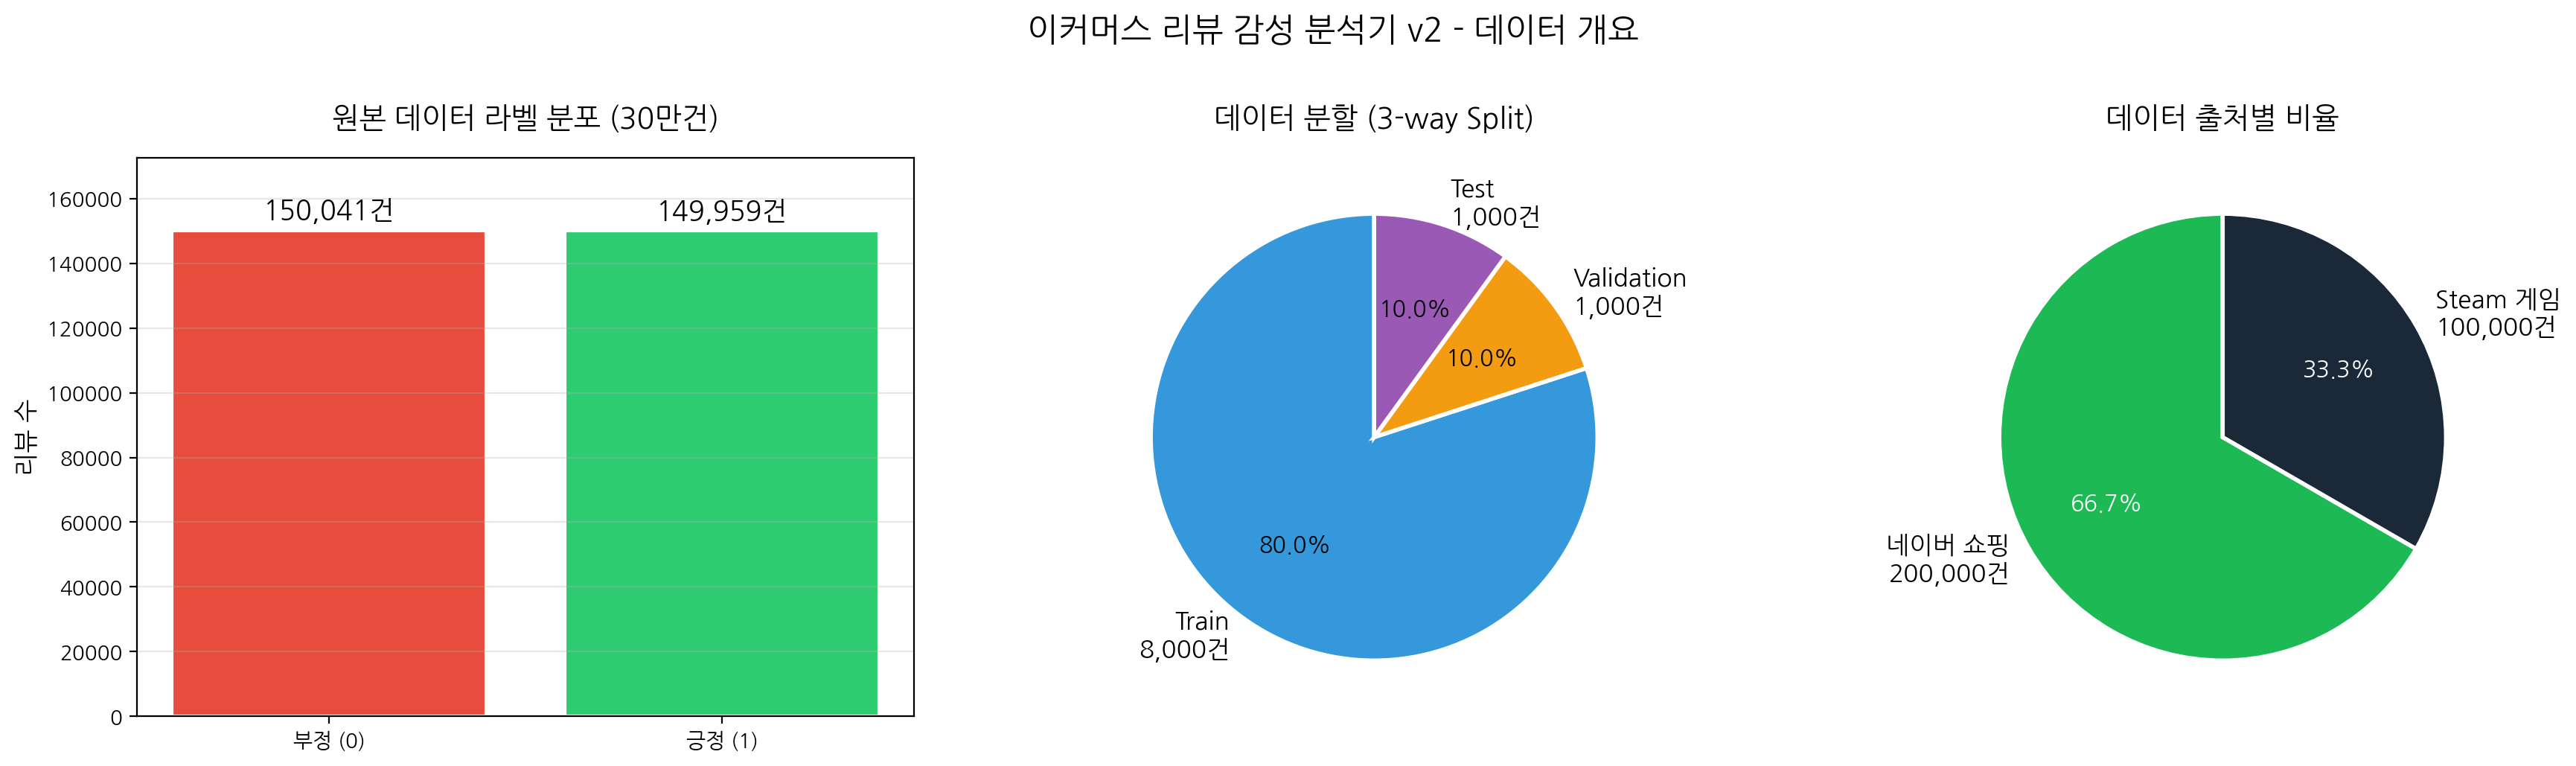

저장 완료: chart_01_data_overview.png


In [115]:
# =============================================================================
# 발표자료 차트 1: 데이터 개요 (라벨 분포 + 데이터 분할 + 출처 비율)
# =============================================================================
# [의도] 발표 슬라이드에서 "어떤 데이터를 사용했는가"를 한 장에 설명하기 위한 차트입니다.
# 청중이 데이터의 규모, 라벨 균형, 분할 전략, 출처 구성을 한눈에 파악할 수 있습니다.
#
# [왜 3개 차트를 1장에 배치하는가?]
#   발표에서 데이터 설명에 할애할 시간이 제한적이므로,
#   관련 정보를 한 장에 모아 효율적으로 전달합니다.
#
# [차트 선택 근거]
#   (1) 막대 그래프: 라벨 간 절대 건수 차이를 직관적으로 비교
#   (2) 파이 차트: 전체 대비 비율을 강조할 때 효과적 (분할 비율, 출처 비율)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib

# 1행 3열 서브플롯: 가로로 넓게 배치하여 발표 슬라이드에 적합한 비율
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ─────────────────────────────────────────────────
# (1) 원본 데이터 라벨 분포
# ─────────────────────────────────────────────────
# [판단 근거] 이진 분류에서 라벨 균형은 모델 성능에 직접적 영향을 줍니다.
# 불균형이 심하면 다수 클래스로 예측을 편향시키므로,
# 데이터가 얼마나 균형적인지 발표 초반에 보여줘야 합니다.
label_counts = raw_df['label'].value_counts().sort_index()
colors_label = ['#E74C3C', '#2ECC71']  # 부정=빨강, 긍정=초록 (직관적 색상 매핑)
bars = axes[0].bar(['부정 (0)', '긍정 (1)'], label_counts.values, color=colors_label, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, label_counts.values):
    # 막대 위에 건수를 표시하여 정확한 수치를 전달합니다.
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}건', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title('원본 데이터 라벨 분포 (30만건)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('리뷰 수', fontsize=12)
axes[0].set_ylim(0, max(label_counts.values) * 1.15)  # 상단 여백 15%
axes[0].grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────────────
# (2) 학습 데이터 분할 비율
# ─────────────────────────────────────────────────
# [판단 근거] 3-way split(Train/Val/Test) 전략을 시각화합니다.
# Val은 모델 선택(Selection)용, Test는 최종 일반화 성능 평가용으로
# 역할이 다르다는 것을 청중에게 전달합니다.
split_sizes = [len(train_df), len(val_df), len(test_df)]
split_labels = [f'Train\n{split_sizes[0]:,}건', f'Validation\n{split_sizes[1]:,}건', f'Test\n{split_sizes[2]:,}건']
colors_split = ['#3498DB', '#F39C12', '#9B59B6']
wedges, texts, autotexts = axes[1].pie(
    split_sizes, labels=split_labels, colors=colors_split,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
axes[1].set_title('데이터 분할 (3-way Split)', fontsize=14, fontweight='bold', pad=15)

# ─────────────────────────────────────────────────
# (3) 데이터 출처별 비율
# ─────────────────────────────────────────────────
# [판단 근거] 두 출처(Naver Shopping, Steam)의 비율을 보여줍니다.
# 출처별로 리뷰 스타일이 다르므로(쇼핑 한줄평 vs 게임 장문 리뷰),
# 모델이 특정 출처에 편향되지 않는지 청중이 판단할 수 있는 근거를 제공합니다.
source_labels = ['네이버 쇼핑\n200,000건', 'Steam 게임\n100,000건']
source_sizes = [200000, 100000]
colors_source = ['#1DB954', '#1B2838']  # 네이버=초록, Steam=진남색 (브랜드 컬러 참고)
wedges2, texts2, autotexts2 = axes[2].pie(
    source_sizes, labels=source_labels, colors=colors_source,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'color': 'black'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts2:
    t.set_fontsize(11)
    t.set_fontweight('bold')
    t.set_color('white')
axes[2].set_title('데이터 출처별 비율', fontsize=14, fontweight='bold', pad=15)

# 전체 차트 제목 + 저장
plt.suptitle('이커머스 리뷰 감성 분석기 v2 - 데이터 개요', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_01_data_overview.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("저장 완료: chart_01_data_overview.png")


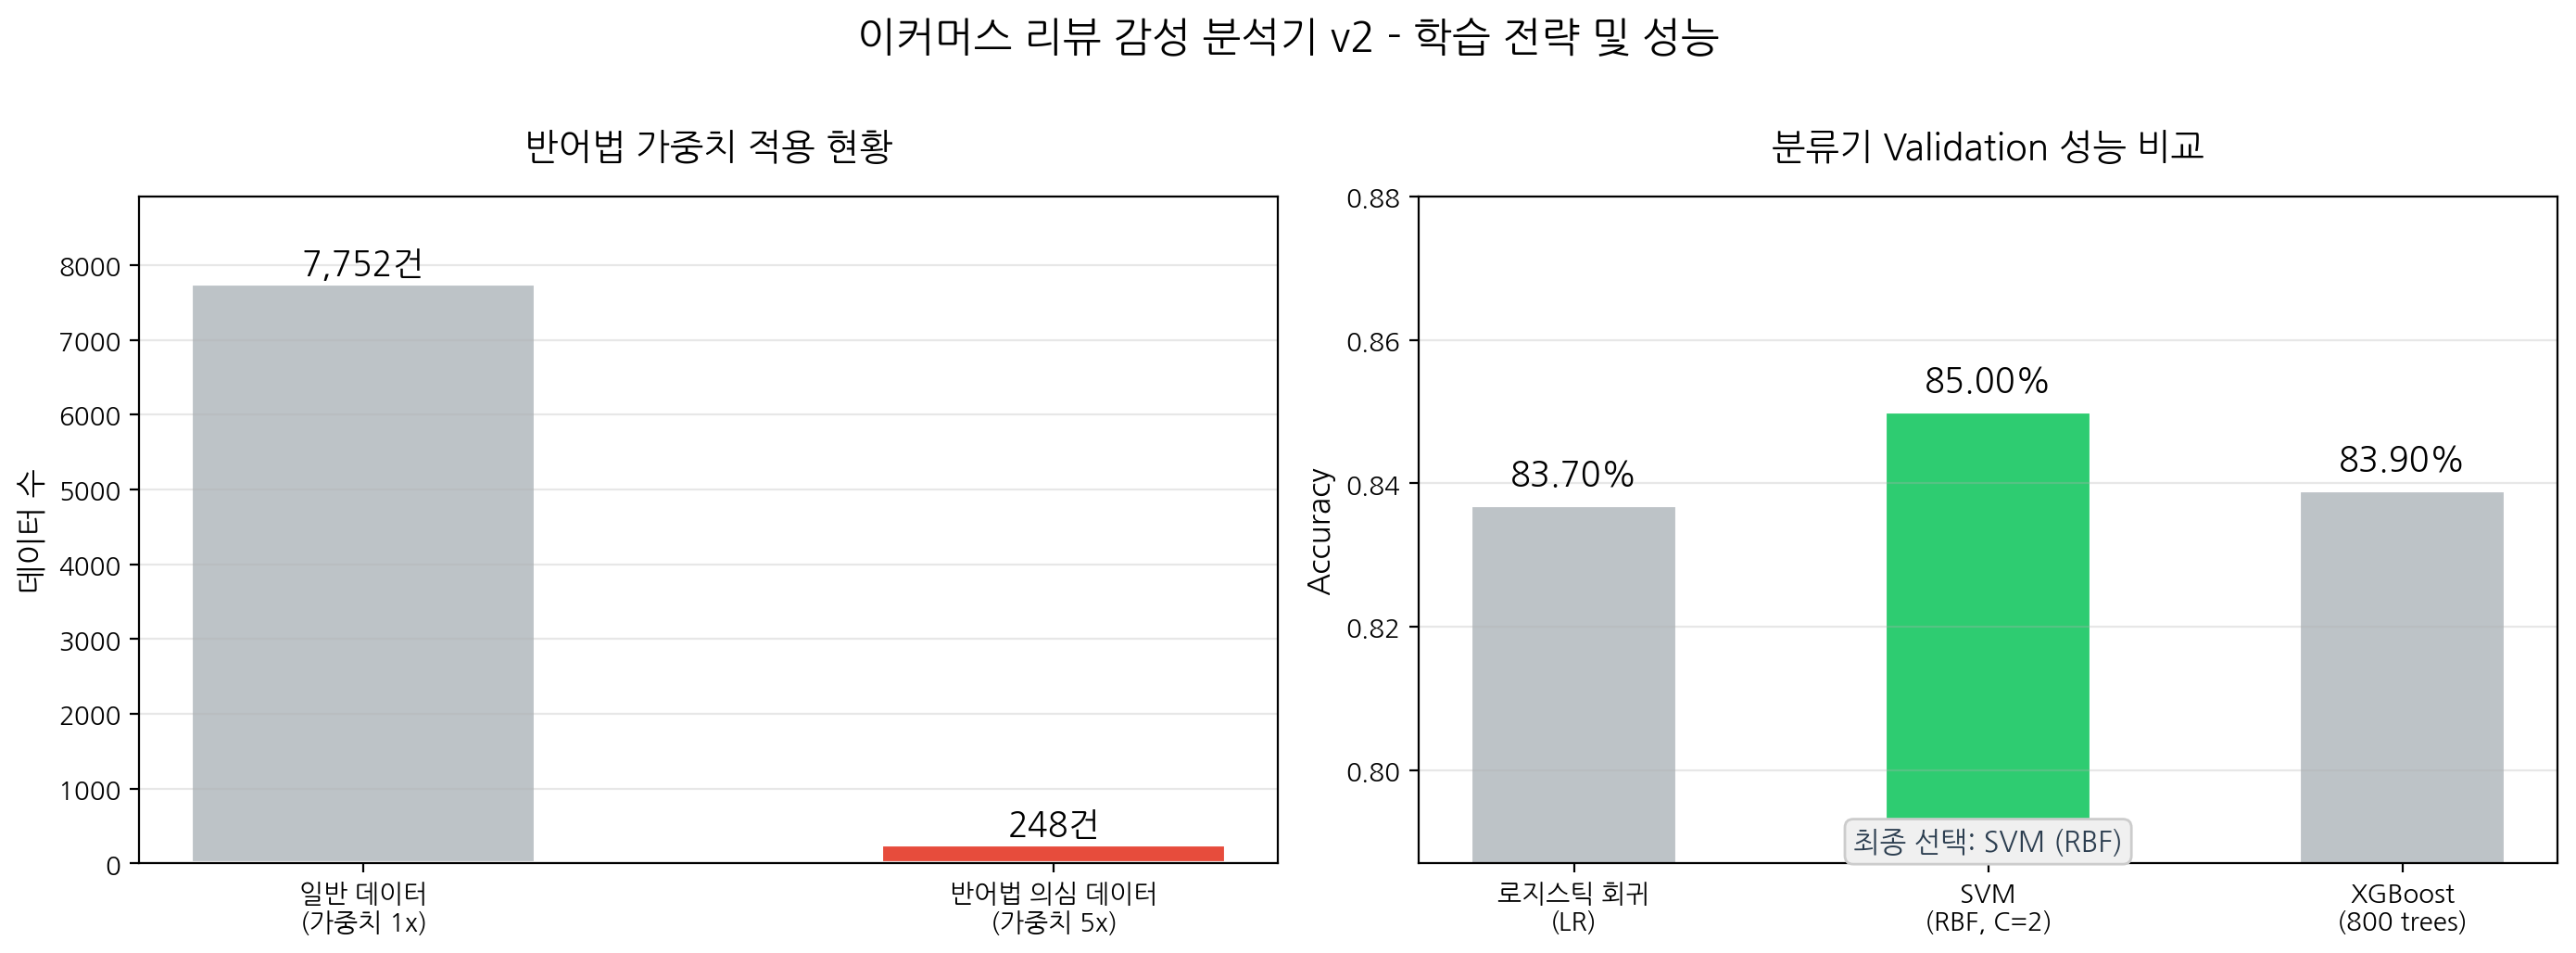

저장 완료: chart_02_training_performance.png


In [116]:
# =============================================================================
# 발표자료 차트 2: 반어법 가중치 적용 현황 + 분류기 성능 비교
# =============================================================================
# [의도] 이 프로젝트의 핵심 차별점인 "반어법 가중치 전략"과
# "3종 분류기 비교" 결과를 발표 슬라이드 1장에 담습니다.
#
# [왜 이 두 차트를 함께 배치하는가?]
#   반어법 가중치는 학습 전략(입력)이고, 분류기 성능은 결과(출력)이므로
#   인과 관계를 한 장에서 보여줄 수 있습니다.
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─────────────────────────────────────────────────
# (1) 반어법 가중치 분포
# ─────────────────────────────────────────────────
# [판단 근거] 전체 학습 데이터 중 반어법 의심 데이터가 차지하는 비율과
# 적용된 가중치 배수를 시각적으로 보여줍니다.
# 일반 데이터(회색)와 반어법 데이터(빨강)의 대비로 규모 차이를 강조합니다.
normal_count = len(weights) - len(sarcastic_neg_samples) - len(sarcastic_pos_samples)
sarcastic_count = len(sarcastic_neg_samples) + len(sarcastic_pos_samples)
categories = ['일반 데이터\n(가중치 1x)', '반어법 의심 데이터\n(가중치 5x)']
counts = [normal_count, sarcastic_count]
colors_w = ['#BDC3C7', '#E74C3C']  # 회색=일반, 빨강=반어법 (주의 환기 색상)

bars = axes[0].bar(categories, counts, color=colors_w, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}건', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title('반어법 가중치 적용 현황', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('데이터 수', fontsize=12)
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────────────
# (2) 분류기 Validation 성능 비교
# ─────────────────────────────────────────────────
# [판단 근거] 3종 분류기(LR, SVM, XGBoost) 중 어떤 모델이 가장 우수한지
# Validation Accuracy로 비교합니다.
# 최고 성능 모델만 컬러로 강조하고 나머지는 회색으로 처리하여
# 최종 선택된 모델이 즉시 식별되도록 합니다.
model_names = ['로지스틱 회귀\n(LR)', 'SVM\n(RBF, C=2)', 'XGBoost\n(800 trees)']
val_accs = [acc_lr_val, acc_svm_val, acc_xgb_val]
colors_clf = ['#3498DB', '#2ECC71', '#E67E22']  # 각 분류기 고유 색상

# 최고 성능 모델만 컬러 유지, 나머지는 회색 처리 (시선 유도)
bar_colors = []
for i, acc in enumerate(val_accs):
    if acc == max(val_accs):
        bar_colors.append(colors_clf[i])
    else:
        bar_colors.append('#BDC3C7')

bars = axes[1].bar(model_names, val_accs, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, val_accs):
    # 막대 위에 정확도를 백분율로 표시합니다.
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.2%}', ha='center', va='bottom', fontsize=13, fontweight='bold')

axes[1].set_title('분류기 Validation 성능 비교', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Accuracy', fontsize=12)
# y축 범위를 최소~최대 근처로 좁혀 성능 차이를 확대 표시합니다.
axes[1].set_ylim(min(val_accs) - 0.05, max(val_accs) + 0.03)
axes[1].grid(axis='y', alpha=0.3)

# 최종 선택 모델을 차트 하단에 명시합니다.
axes[1].annotate(f'최종 선택: {best_name}', xy=(0.5, 0.02), xycoords='axes fraction',
                 ha='center', fontsize=11, style='italic', color='#2C3E50',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.suptitle('이커머스 리뷰 감성 분석기 v2 - 학습 전략 및 성능', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_02_training_performance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("저장 완료: chart_02_training_performance.png")


---
## 발표 자료: 임베딩 모델 비교 (ko-sroberta vs E5 vs BGE-M3)

In [117]:
# =============================================================================
# 임베딩 모델 비교: ko-sroberta vs E5 vs BGE-M3 (발표 자료용)
# =============================================================================
# [의도] 세 가지 임베딩 모델을 동일 조건에서 비교하여
# MGE-M3 모델을 최종 선택한 근거를 정량적으로 제시합니다.
#
# [비교 대상]
#   1) jhgan/ko-sroberta-multitask: 한국어 STS/NLI 특화 임베딩 모델
#   2) intfloat/multilingual-e5-base: 대조 학습 기반 다국어 임베딩 모델
#   3) BAAI/bge-m3 : 다기능 학습을 통해 문맥 파악 기능 특화 임베딩 모델 (현재 사용 중)
#
# [동일 조건]
#   - 동일한 학습/검증/테스트 데이터 (8K/1K/1K)
#   - 동일한 3종 분류기 (LR, SVM, XGBoost)
#   - 동일한 반어법 가중치 (5x)
#   - 동일한 하이퍼파라미터
#
# [실행 순서]
#   1. ko-sroberta 모델 로드 및 임베딩 생성
#   2. 동일한 3종 분류기 학습
#   3. E5 모델 로드 및 임베딩 생성
#   4. 동일한 3종 분류기 학습
#   3. BGE-M3 모델 결과와 비교하는 표 출력
# =============================================================================
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import time

# ─────────────────────────────────────────────────
# 1) ko-sroberta 모델 로드 + 임베딩
# ─────────────────────────────────────────────────
print("=" * 60)
print("  [Step 1] ko-sroberta 모델 로드 및 임베딩 생성")
print("=" * 60)

model_sroberta = SentenceTransformer("jhgan/ko-sroberta-multitask")

def embed_texts_sroberta(texts, desc="임베딩"):
    """ko-sroberta용 임베딩 함수 (query: 접두사 불필요)"""
    return model_sroberta.encode(
        texts,
        convert_to_numpy=True,
        show_progress_bar=True,
        batch_size=64
    )

start_time = time.time()
print("train 임베딩 중... (ko-sroberta, 768차원)")
X_train_sr = embed_texts_sroberta(train_df["text"].tolist(), "train")
print("validation 임베딩 중...")
X_val_sr = embed_texts_sroberta(val_df["text"].tolist(), "val")
print("test 임베딩 중...")
X_test_sr = embed_texts_sroberta(test_df["text"].tolist(), "test")
sr_embed_time = time.time() - start_time
print(f"\nko-sroberta 임베딩 완료: {sr_embed_time:.1f}초")
print(f"shape: train {X_train_sr.shape}, val {X_val_sr.shape}, test {X_test_sr.shape}")

# ─────────────────────────────────────────────────
# 2) ko-sroberta 임베딩으로 분류기 학습
# ─────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print("  [Step 2] ko-sroberta 임베딩으로 분류기 학습")
print("=" * 60)

# 동일한 가중치(weights)를 사용하여 공정한 비교를 합니다.
print("[1/3] 로지스틱 회귀 학습 중...")
clf_lr_sr = LogisticRegression(max_iter=2000, random_state=42)
clf_lr_sr.fit(X_train_sr, y_train, sample_weight=weights)
acc_lr_val_sr = clf_lr_sr.score(X_val_sr, y_val)
acc_lr_test_sr = clf_lr_sr.score(X_test_sr, y_test)
print(f"   -> Val: {acc_lr_val_sr:.4f}, Test: {acc_lr_test_sr:.4f}")

print("[2/3] SVM (RBF) 학습 중...")
clf_svm_sr = SVC(kernel='rbf', C=2, gamma='scale', probability=True, random_state=42)
clf_svm_sr.fit(X_train_sr, y_train, sample_weight=weights)
acc_svm_val_sr = clf_svm_sr.score(X_val_sr, y_val)
acc_svm_test_sr = clf_svm_sr.score(X_test_sr, y_test)
print(f"   -> Val: {acc_svm_val_sr:.4f}, Test: {acc_svm_test_sr:.4f}")

print("[3/3] XGBoost 학습 중...")
clf_xgb_sr = XGBClassifier(
    n_estimators=800, learning_rate=0.05, max_depth=6,
    eval_metric='logloss', random_state=42
)
clf_xgb_sr.fit(X_train_sr, y_train, sample_weight=weights)
acc_xgb_val_sr = clf_xgb_sr.score(X_val_sr, y_val)
acc_xgb_test_sr = clf_xgb_sr.score(X_test_sr, y_test)
print(f"   -> Val: {acc_xgb_val_sr:.4f}, Test: {acc_xgb_test_sr:.4f}")

# ko-sroberta 최고 성능 모델 선택
sr_val_scores = {'LR': acc_lr_val_sr, 'SVM': acc_svm_val_sr, 'XGBoost': acc_xgb_val_sr}
sr_test_scores = {'LR': acc_lr_test_sr, 'SVM': acc_svm_test_sr, 'XGBoost': acc_xgb_test_sr}
sr_best_name = max(sr_val_scores, key=sr_val_scores.get)
sr_best_val = sr_val_scores[sr_best_name]
sr_best_test = sr_test_scores[sr_best_name]



  [Step 1] ko-sroberta 모델 로드 및 임베딩 생성


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


train 임베딩 중... (ko-sroberta, 768차원)


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

validation 임베딩 중...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

test 임베딩 중...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


ko-sroberta 임베딩 완료: 18.1초
shape: train (8000, 768), val (1000, 768), test (1000, 768)

  [Step 2] ko-sroberta 임베딩으로 분류기 학습
[1/3] 로지스틱 회귀 학습 중...
   -> Val: 0.8230, Test: 0.8580
[2/3] SVM (RBF) 학습 중...
   -> Val: 0.8420, Test: 0.8780
[3/3] XGBoost 학습 중...
   -> Val: 0.8280, Test: 0.8720


In [118]:
# ─────────────────────────────────────────────────
# 3) E5 모델 로드 + 임베딩
# ─────────────────────────────────────────────────
print("=" * 60)
print("  [Step 3] E5 모델 로드 및 임베딩 생성")
print("=" * 60)

model_e5 = SentenceTransformer("intfloat/multilingual-e5-base")

def embed_texts_e5(texts, desc="임베딩"):
    """E5용 임베딩 함수 (성능 극대화를 위해 'query: ' 접두사 추가)"""
    preprocessed_texts = [f"query: {text}" for text in texts]
    return model_e5.encode(
        preprocessed_texts,
        convert_to_numpy=True,
        show_progress_bar=True,
        batch_size=64
    )

start_time = time.time()
print("train 임베딩 중... (E5, 768차원)")
X_train_e5 = embed_texts_e5(train_df["text"].tolist(), "train")
print("validation 임베딩 중...")
X_val_e5 = embed_texts_e5(val_df["text"].tolist(), "val")
print("test 임베딩 중...")
X_test_e5 = embed_texts_e5(test_df["text"].tolist(), "test")
e5_embed_time = time.time() - start_time
print(f"\nE5 임베딩 완료: {e5_embed_time:.1f}초")
print(f"shape: train {X_train_e5.shape}, val {X_val_e5.shape}, test {X_test_e5.shape}")

# ─────────────────────────────────────────────────
# 4) E5 임베딩으로 분류기 학습
# ─────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print("  [Step 4] E5 임베딩으로 분류기 학습")
print("=" * 60)

# 동일한 가중치(weights)를 사용하여 공정한 비교를 합니다.
print("[1/3] 로지스틱 회귀 학습 중...")
clf_lr_e5 = LogisticRegression(max_iter=2000, random_state=42)
clf_lr_e5.fit(X_train_e5, y_train, sample_weight=weights)
acc_lr_val_e5 = clf_lr_e5.score(X_val_e5, y_val)
acc_lr_test_e5 = clf_lr_e5.score(X_test_e5, y_test)
print(f"   -> Val: {acc_lr_val_e5:.4f}, Test: {acc_lr_test_e5:.4f}")

print("[2/3] SVM (RBF) 학습 중...")
clf_svm_e5 = SVC(kernel='rbf', C=2, gamma='scale', probability=True, random_state=42)
clf_svm_e5.fit(X_train_e5, y_train, sample_weight=weights)
acc_svm_val_e5 = clf_svm_e5.score(X_val_e5, y_val)
acc_svm_test_e5 = clf_svm_e5.score(X_test_e5, y_test)
print(f"   -> Val: {acc_svm_val_e5:.4f}, Test: {acc_svm_test_e5:.4f}")

print("[3/3] XGBoost 학습 중...")
clf_xgb_e5 = XGBClassifier(
    n_estimators=800, learning_rate=0.05, max_depth=6,
    eval_metric='logloss', random_state=42
)
clf_xgb_e5.fit(X_train_e5, y_train, sample_weight=weights)
acc_xgb_val_e5 = clf_xgb_e5.score(X_val_e5, y_val)
acc_xgb_test_e5 = clf_xgb_e5.score(X_test_e5, y_test)
print(f"   -> Val: {acc_xgb_val_e5:.4f}, Test: {acc_xgb_test_e5:.4f}")

# E5 최고 성능 모델 선택
e5_val_scores = {'LR': acc_lr_val_e5, 'SVM': acc_svm_val_e5, 'XGBoost': acc_xgb_val_e5}
e5_test_scores = {'LR': acc_lr_test_e5, 'SVM': acc_svm_test_e5, 'XGBoost': acc_xgb_test_e5}
e5_best_name = max(e5_val_scores, key=e5_val_scores.get)
e5_best_val = e5_val_scores[e5_best_name]
e5_best_test = e5_test_scores[e5_best_name]

  [Step 3] E5 모델 로드 및 임베딩 생성


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


train 임베딩 중... (E5, 768차원)


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

validation 임베딩 중...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

test 임베딩 중...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


E5 임베딩 완료: 19.9초
shape: train (8000, 768), val (1000, 768), test (1000, 768)

  [Step 4] E5 임베딩으로 분류기 학습
[1/3] 로지스틱 회귀 학습 중...
   -> Val: 0.8130, Test: 0.8490
[2/3] SVM (RBF) 학습 중...
   -> Val: 0.8160, Test: 0.8570
[3/3] XGBoost 학습 중...
   -> Val: 0.8220, Test: 0.8540


In [119]:
# ─────────────────────────────────────────────────
# 5) 임베딩 모델별 성능 비교 표 출력
# ─────────────────────────────────────────────────
print(f"\n{'=' * 75}")
print(f"  [발표 자료] 임베딩 모델별 분류기 성능 비교")
print(f"{'=' * 75}")
print(f"  {'임베딩 모델':<20} {'분류기':<16} {'Val Acc':>10} {'Test Acc':>10}")
print(f"{'-' * 75}")

# ko-sroberta 결과
print(f"  {'ko-sroberta':<20} {'로지스틱 회귀':<16} {acc_lr_val_sr:>10.4f} {acc_lr_test_sr:>10.4f}")
print(f"  {'':<20} {'SVM (RBF)':<16} {acc_svm_val_sr:>10.4f} {acc_svm_test_sr:>10.4f}")
print(f"  {'':<20} {'XGBoost':<16} {acc_xgb_val_sr:>10.4f} {acc_xgb_test_sr:>10.4f}")
print(f"{'-' * 75}")

# E5 결과
print(f"  {'E5 (multilingual)':<20} {'로지스틱 회귀':<16} {acc_lr_val_e5:>10.4f} {acc_lr_test_e5:>10.4f}")
print(f"  {'':<20} {'SVM (RBF)':<16} {acc_svm_val_e5:>10.4f} {acc_svm_test_e5:>10.4f}")
print(f"  {'':<20} {'XGBoost':<16} {acc_xgb_val_e5:>10.4f} {acc_xgb_test_e5:>10.4f}")
print(f"{'-' * 75}")

# BGE-M3 결과 (이미 학습된 변수들을 재활용)
print(f"  {'BGE-M3':<20} {'로지스틱 회귀':<16} {acc_lr_val:>10.4f} {acc_lr_test:>10.4f}")
print(f"  {'':<20} {'SVM (RBF)':<16} {acc_svm_val:>10.4f} {acc_svm_test:>10.4f}")
print(f"  {'':<20} {'XGBoost':<16} {acc_xgb_val:>10.4f} {acc_xgb_test:>10.4f}")
print(f"{'=' * 75}")

# 최고 성능 비교 요약
print(f"\n  [요약]")
print(f"  ko-sroberta 최고 성능: {sr_best_name} (Val {sr_best_val:.4f}, Test {sr_best_test:.4f})")
print(f"  E5 (multilingual) 최고 성능: {e5_best_name} (Val {e5_best_val:.4f}, Test {e5_best_test:.4f})")
print(f"  BGE-M3 최고 성능:          {best_name} (Val {best_val_acc:.4f}, Test {acc_test:.4f})")


  [발표 자료] 임베딩 모델별 분류기 성능 비교
  임베딩 모델               분류기                 Val Acc   Test Acc
---------------------------------------------------------------------------
  ko-sroberta          로지스틱 회귀              0.8230     0.8580
                       SVM (RBF)            0.8420     0.8780
                       XGBoost              0.8280     0.8720
---------------------------------------------------------------------------
  E5 (multilingual)    로지스틱 회귀              0.8130     0.8490
                       SVM (RBF)            0.8160     0.8570
                       XGBoost              0.8220     0.8540
---------------------------------------------------------------------------
  BGE-M3               로지스틱 회귀              0.8370     0.8810
                       SVM (RBF)            0.8500     0.8800
                       XGBoost              0.8390     0.8810

  [요약]
  ko-sroberta 최고 성능: SVM (Val 0.8420, Test 0.8780)
  E5 (multilingual) 최고 성능: XGBoost (Val 0.8220, Test 0.8540)
  B

In [120]:
# =============================================================================
# 성능 차이 계산: BGE-M3 vs ko-sroberta vs E5
# =============================================================================

# 1. BGE-M3 vs ko-sroberta 차이 계산
diff_val_sr = best_val_acc - sr_best_val
diff_test_sr = acc_test - sr_best_test

# 2. BGE-M3 vs E5 차이 계산
diff_val_e5 = best_val_acc - e5_best_val
diff_test_e5 = acc_test - e5_best_test

print("=" * 60)
print(f" 🔍 [최종 모델 비교 보고서: BGE-M3 기준]")
print("=" * 60)

# ko-sroberta와 비교 출력
print(f" 1) vs ko-sroberta :")
print(f"    - Val:  {diff_val_sr:+.4f}")
print(f"    - Test: {diff_test_sr:+.4f} ({'높은' if diff_test_sr > 0 else '낮은'} 성능)")

# E5와 비교 출력
print(f"\n 2) vs E5 :")
print(f"    - Val:  {diff_val_e5:+.4f}")
print(f"    - Test: {diff_test_e5:+.4f} ({'높은' if diff_test_e5 > 0 else '낮은'} 성능)")

print("-" * 60)

# 최종 결론 출력 (BGE-M3가 가장 우수할 경우)
if acc_test > e5_best_test and acc_test > sr_best_test:
    print(f" ✅ 결론: BGE-M3 모델이 하이브리드 학습 기반의 깊은 문맥 이해력으로")
    print(f"    가장 우수한 성능을 보여 최종 모델로 선정되었습니다.")
else:
    print(f" ⚠️ 결론: 지표에 따라 성능 차이가 있으므로, 속도와 정확도의 트레이드오프를 고려해야 합니다.")

 🔍 [최종 모델 비교 보고서: BGE-M3 기준]
 1) vs ko-sroberta :
    - Val:  +0.0080
    - Test: +0.0020 (높은 성능)

 2) vs E5 :
    - Val:  +0.0280
    - Test: +0.0260 (높은 성능)
------------------------------------------------------------
 ✅ 결론: BGE-M3 모델이 하이브리드 학습 기반의 깊은 문맥 이해력으로
    가장 우수한 성능을 보여 최종 모델로 선정되었습니다.


In [121]:
# # =============================================================================
# # 발표자료 차트 6: 임베딩 모델 비교 차트 (ko-sroberta vs E5 vs BGE-M3)
# # =============================================================================
# # [의도] 세 임베딩 모델의 성능 차이를 시각적으로 명확히 보여줍니다.
# # 발표에서 "BGE-M3를 선택한 이유"를 한눈에 설명할 수 있는 핵심 차트입니다.
# #
# # [차트 구성]
# #   좌측: 분류기별 Test Accuracy 비교 (그룹 막대 차트)
# #   우측: 세 모델의 특성 비교 (레이더/요약 차트)
# #
# # [왜 그룹 막대 차트인가?]
# #   세 모델 × 3개 분류기 = 6개 값을 동시에 비교해야 하므로
# #   그룹화된 막대 차트가 가장 직관적입니다.
# # =============================================================================
# import matplotlib.pyplot as plt
# import numpy as np

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # ─────────────────────────────────────────────────
# # (1) 분류기별 Test Accuracy 비교 (그룹 막대 차트)
# # ─────────────────────────────────────────────────
# classifiers = ['로지스틱 회귀\n(LR)', 'SVM\n(RBF)', 'XGBoost']

# # ko-sroberta 결과
# sr_test_accs = [acc_lr_test_sr, acc_svm_test_sr, acc_xgb_test_sr]
# # E5 결과
# e5_test_accs = [acc_lr_test, acc_svm_test, acc_xgb_test]

# x = np.arange(len(classifiers))
# width = 0.3

# bars1 = axes[0].bar(x - width/2, sr_test_accs, width,
#                      label='ko-sroberta', color='#BDC3C7', edgecolor='white', linewidth=1.5)
# bars2 = axes[0].bar(x + width/2, e5_test_accs, width,
#                      label='E5 (multilingual)', color='#3498DB', edgecolor='white', linewidth=1.5)

# # 각 막대 위에 정확도 수치 표시
# for bar, val in zip(bars1, sr_test_accs):
#     axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
#                  f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#7F8C8D')
# for bar, val in zip(bars2, e5_test_accs):
#     axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
#                  f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2980B9')

# axes[0].set_title('임베딩 모델별 Test Accuracy 비교', fontsize=14, fontweight='bold', pad=15)
# axes[0].set_xticks(x)
# axes[0].set_xticklabels(classifiers, fontsize=11)
# axes[0].set_ylabel('Test Accuracy', fontsize=12)
# axes[0].legend(fontsize=11, loc='lower right')
# axes[0].grid(axis='y', alpha=0.3)

# # Y축 범위: 최솟값에서 약간 아래부터 시작하여 차이를 강조합니다.
# all_accs = sr_test_accs + e5_test_accs
# y_min = min(all_accs) - 0.02
# y_max = max(all_accs) + 0.02
# axes[0].set_ylim(y_min, min(y_max, 1.0))

# # ─────────────────────────────────────────────────
# # (2) 모델 특성 비교 요약 표 (텍스트 기반)
# # ─────────────────────────────────────────────────
# axes[1].axis('off')

# # 비교 항목을 표 형태로 정리합니다.
# comparison_data = [
#     ['항목', 'ko-sroberta', 'E5 (multilingual)'],
#     ['모델 유형', '한국어 특화\n(STS/NLI)', '다국어 대조학습\n(Contrastive)'],
#     ['임베딩 차원', '768', '768'],
#     ['입력 전처리', '없음', '"query: " 접두사'],
#     ['LR Test Acc', f'{acc_lr_test_sr:.4f}', f'{acc_lr_test:.4f}'],
#     ['SVM Test Acc', f'{acc_svm_test_sr:.4f}', f'{acc_svm_test:.4f}'],
#     ['XGB Test Acc', f'{acc_xgb_test_sr:.4f}', f'{acc_xgb_test:.4f}'],
#     ['최고 성능', f'{sr_best_name}: {sr_best_test:.4f}', f'{best_name}: {float(acc_test):.4f}'],
# ]

# # matplotlib 표 생성
# table = axes[1].table(
#     cellText=[row for row in comparison_data],
#     cellLoc='center',
#     loc='center',
#     colWidths=[0.25, 0.35, 0.35]
# )

# # 표 스타일 설정
# table.auto_set_font_size(False)
# table.set_fontsize(11)
# table.scale(1, 2.0)

# # 헤더 행 스타일
# for j in range(3):
#     cell = table[0, j]
#     cell.set_facecolor('#2C3E50')
#     cell.set_text_props(color='white', fontweight='bold')

# # 마지막 행(최고 성능) 강조
# for j in range(3):
#     cell = table[len(comparison_data)-1, j]
#     cell.set_facecolor('#EBF5FB')
#     cell.set_text_props(fontweight='bold')

# # E5가 더 높은 Test Acc 셀에 초록 배경 표시
# for i in range(4, 7):  # LR/SVM/XGB Test Acc 행
#     sr_val = float(comparison_data[i][1])
#     e5_val = float(comparison_data[i][2])
#     if e5_val > sr_val:
#         table[i, 2].set_facecolor('#D5F5E3')  # E5 승리: 연초록
#     elif sr_val > e5_val:
#         table[i, 1].set_facecolor('#D5F5E3')  # sroberta 승리: 연초록

# axes[1].set_title('임베딩 모델 특성 비교', fontsize=14, fontweight='bold', pad=15)

# plt.suptitle('임베딩 모델 비교: ko-sroberta vs E5 (multilingual)',
#              fontsize=16, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.savefig('chart_06_embedding_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()
# print("저장 완료: chart_06_embedding_comparison.png")

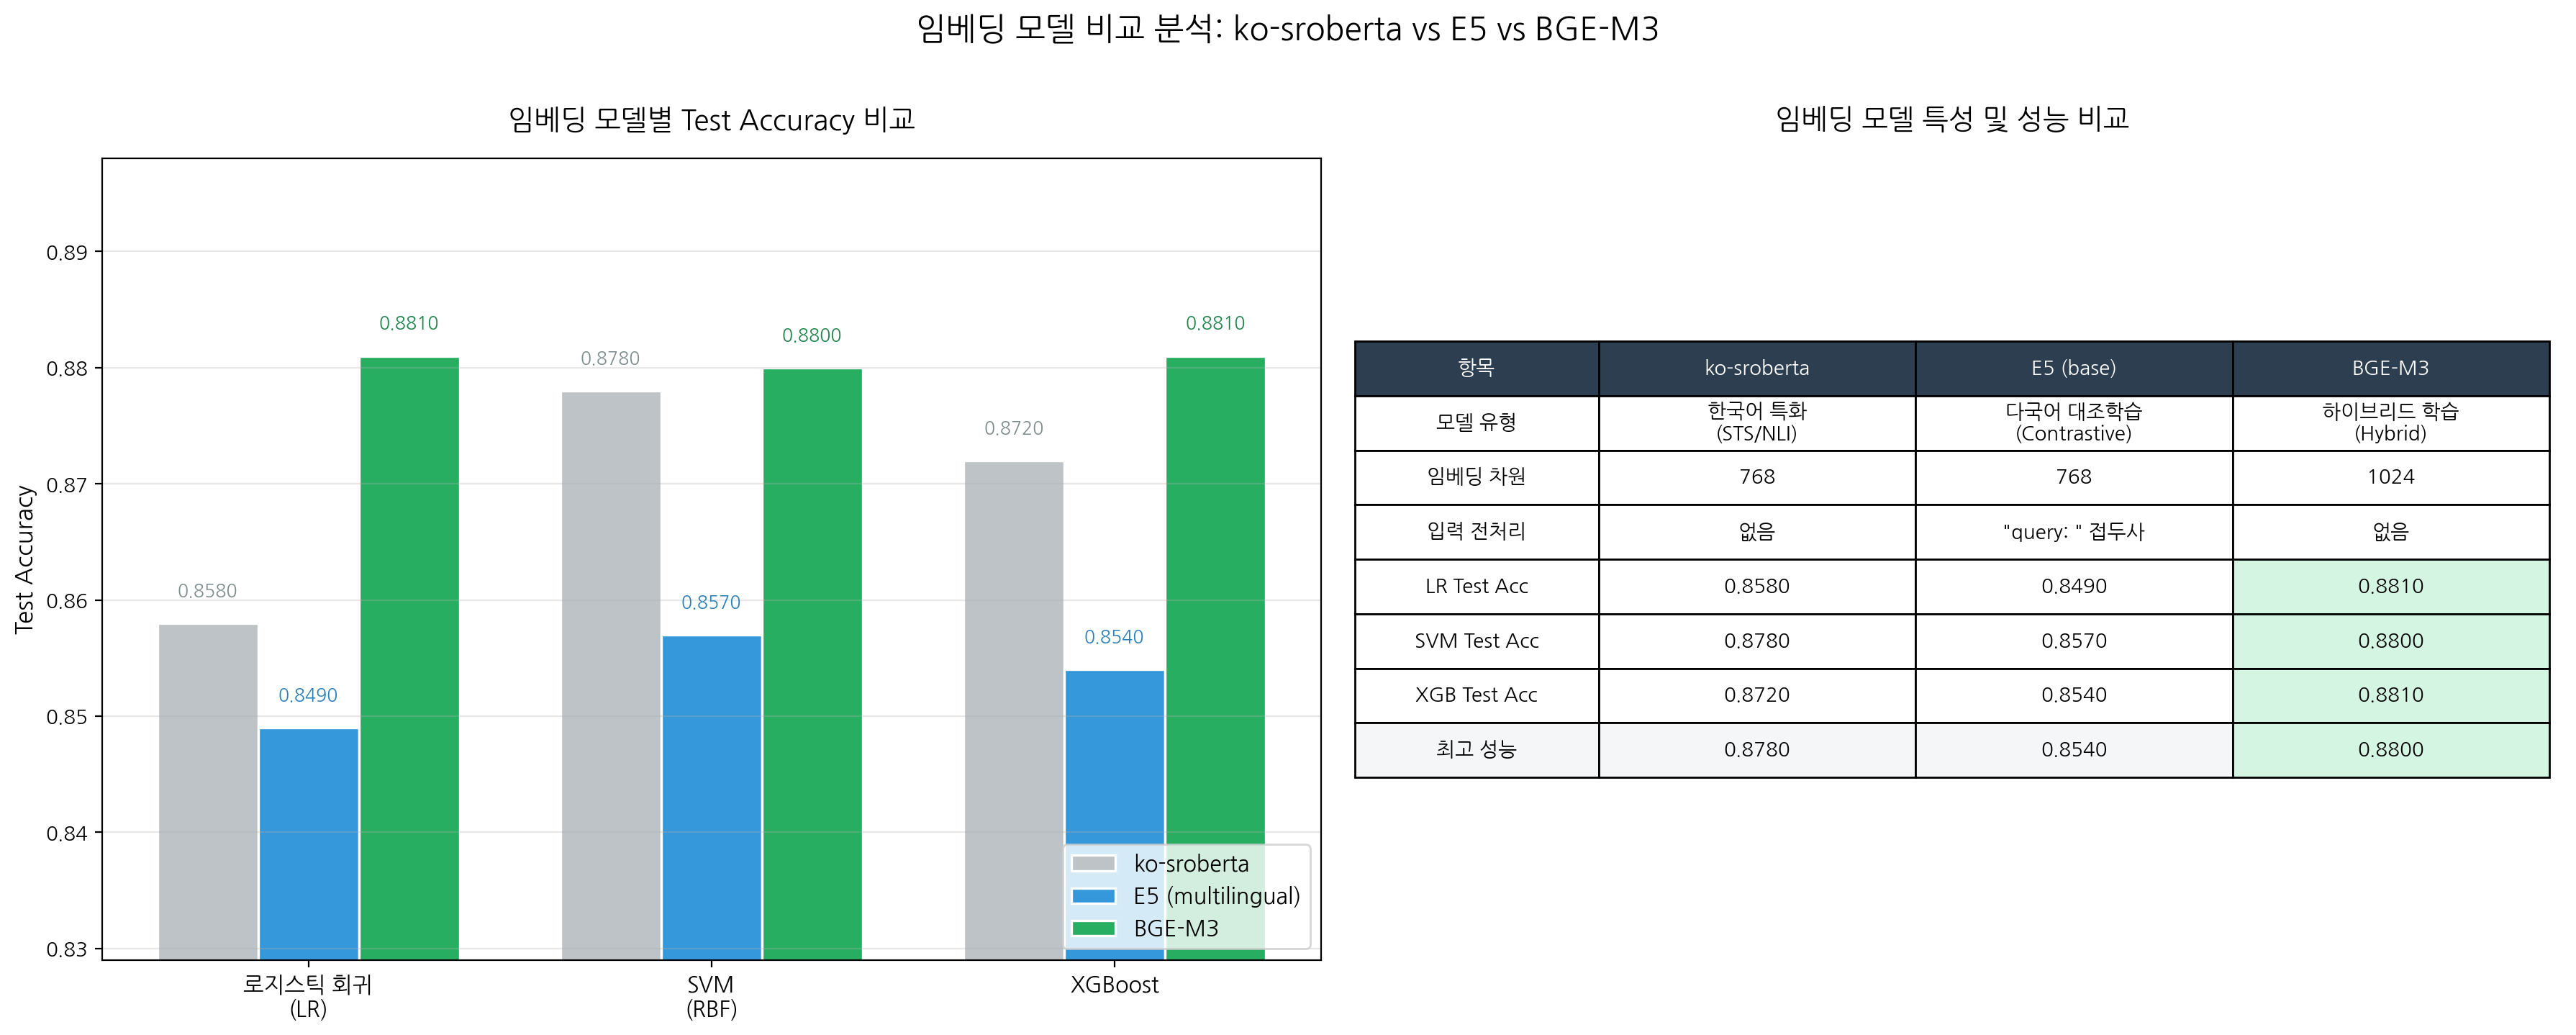

저장 완료: chart_06_embedding_comparison_v2.png


In [122]:
# =============================================================================
# 발표자료 차트 6: 임베딩 모델 비교 차트 (ko-sroberta vs E5 vs BGE-M3)
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# 3개 모델 비교를 위해 가로 폭을 18로 약간 확장합니다.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ─────────────────────────────────────────────────
# (1) 분류기별 Test Accuracy 비교 (그룹 막대 차트)
# ─────────────────────────────────────────────────
classifiers = ['로지스틱 회귀\n(LR)', 'SVM\n(RBF)', 'XGBoost']

# 각 모델별 결과 (기존 변수명 유지 및 BGE 추가)
sr_test_accs = [acc_lr_test_sr, acc_svm_test_sr, acc_xgb_test_sr]
e5_test_accs = [acc_lr_test_e5, acc_svm_test_e5, acc_xgb_test_e5]
bge_test_accs = [acc_lr_test, acc_svm_test, acc_xgb_test]

x = np.arange(len(classifiers))
width = 0.25  # 3개 막대를 배치하기 위해 너비 조절

bars1 = axes[0].bar(x - width, sr_test_accs, width, label='ko-sroberta',
                    color='#BDC3C7', edgecolor='white', linewidth=1.2)
bars2 = axes[0].bar(x, e5_test_accs, width, label='E5 (multilingual)',
                    color='#3498DB', edgecolor='white', linewidth=1.2)
bars3 = axes[0].bar(x + width, bge_test_accs, width, label='BGE-M3',
                    color='#27AE60', edgecolor='white', linewidth=1.2)

# 각 막대 위에 수치 표시 함수
def add_labels(bars, color):
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.002,
                     f'{height:.4f}', ha='center', va='bottom',
                     fontsize=9, fontweight='bold', color=color)

add_labels(bars1, '#7F8C8D')
add_labels(bars2, '#2980B9')
add_labels(bars3, '#1E8449')

axes[0].set_title('임베딩 모델별 Test Accuracy 비교', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classifiers, fontsize=11)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# Y축 범위: 최솟값에서 약간 아래부터 시작하여 차이를 강조합니다.
all_accs = sr_test_accs + e5_test_accs
y_min = min(all_accs) - 0.02
y_max = max(all_accs) + 0.02
axes[0].set_ylim(y_min, min(y_max, 1.0))

# ─────────────────────────────────────────────────
# (2) 모델 특성 비교 요약 표 (BGE-M3 포함 3개 모델)
# ─────────────────────────────────────────────────
axes[1].axis('off')

# 비교 항목을 표 형태로 정리 (BGE-M3 컬럼 추가)
comparison_data = [
    ['항목', 'ko-sroberta', 'E5 (base)', 'BGE-M3'],
    ['모델 유형', '한국어 특화\n(STS/NLI)', '다국어 대조학습\n(Contrastive)', '하이브리드 학습\n(Hybrid)'],
    ['임베딩 차원', '768', '768', '1024'],
    ['입력 전처리', '없음', '"query: " 접두사', '없음'],
    ['LR Test Acc', f'{acc_lr_test_sr:.4f}', f'{acc_lr_test_e5:.4f}', f'{acc_lr_test:.4f}'],
    ['SVM Test Acc', f'{acc_svm_test_sr:.4f}', f'{acc_svm_test_e5:.4f}', f'{acc_svm_test:.4f}'],
    ['XGB Test Acc', f'{acc_xgb_test_sr:.4f}', f'{acc_xgb_test_e5:.4f}', f'{acc_xgb_test:.4f}'],
    ['최고 성능', f'{sr_best_test:.4f}', f'{e5_best_test:.4f}', f'{acc_test:.4f}'],
]

# matplotlib 표 생성 (컬럼이 4개이므로 colWidths 조정)
table = axes[1].table(
    cellText=[row for row in comparison_data],
    cellLoc='center',
    loc='center',
    colWidths=[0.20, 0.26, 0.26, 0.26]
)

# 표 스타일 설정
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2) # 행 높이를 약간 높여 가독성 확보

# 헤더 행 스타일 (Dark Navy)
for j in range(4):
    cell = table[0, j]
    cell.set_facecolor('#2C3E50')
    cell.set_text_props(color='white', fontweight='bold')

# 마지막 행(최고 성능 요약) 배경 강조
for j in range(4):
    cell = table[len(comparison_data)-1, j]
    cell.set_facecolor('#F4F6F7')
    cell.set_text_props(fontweight='bold')

# [지능형 하이라이트] 각 지표별(LR/SVM/XGB/최고성능) 1등 셀에 초록색 배경 표시
for i in range(4, 8):  # LR Test Acc 행부터 최고 성능 행까지
    # 각 셀의 텍스트 값을 숫자로 변환하여 비교
    vals = [float(comparison_data[i][1]), float(comparison_data[i][2]), float(comparison_data[i][3])]
    max_idx = vals.index(max(vals)) + 1 # 0번째 열(항목명)을 제외하므로 +1

    table[i, max_idx].set_facecolor('#D5F5E3') # 승리 모델 셀: 연초록
    table[i, max_idx].set_text_props(fontweight='bold')

axes[1].set_title('임베딩 모델 특성 및 성능 비교', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('임베딩 모델 비교 분석: ko-sroberta vs E5 vs BGE-M3',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_06_embedding_comparison_v2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("저장 완료: chart_06_embedding_comparison_v2.png")

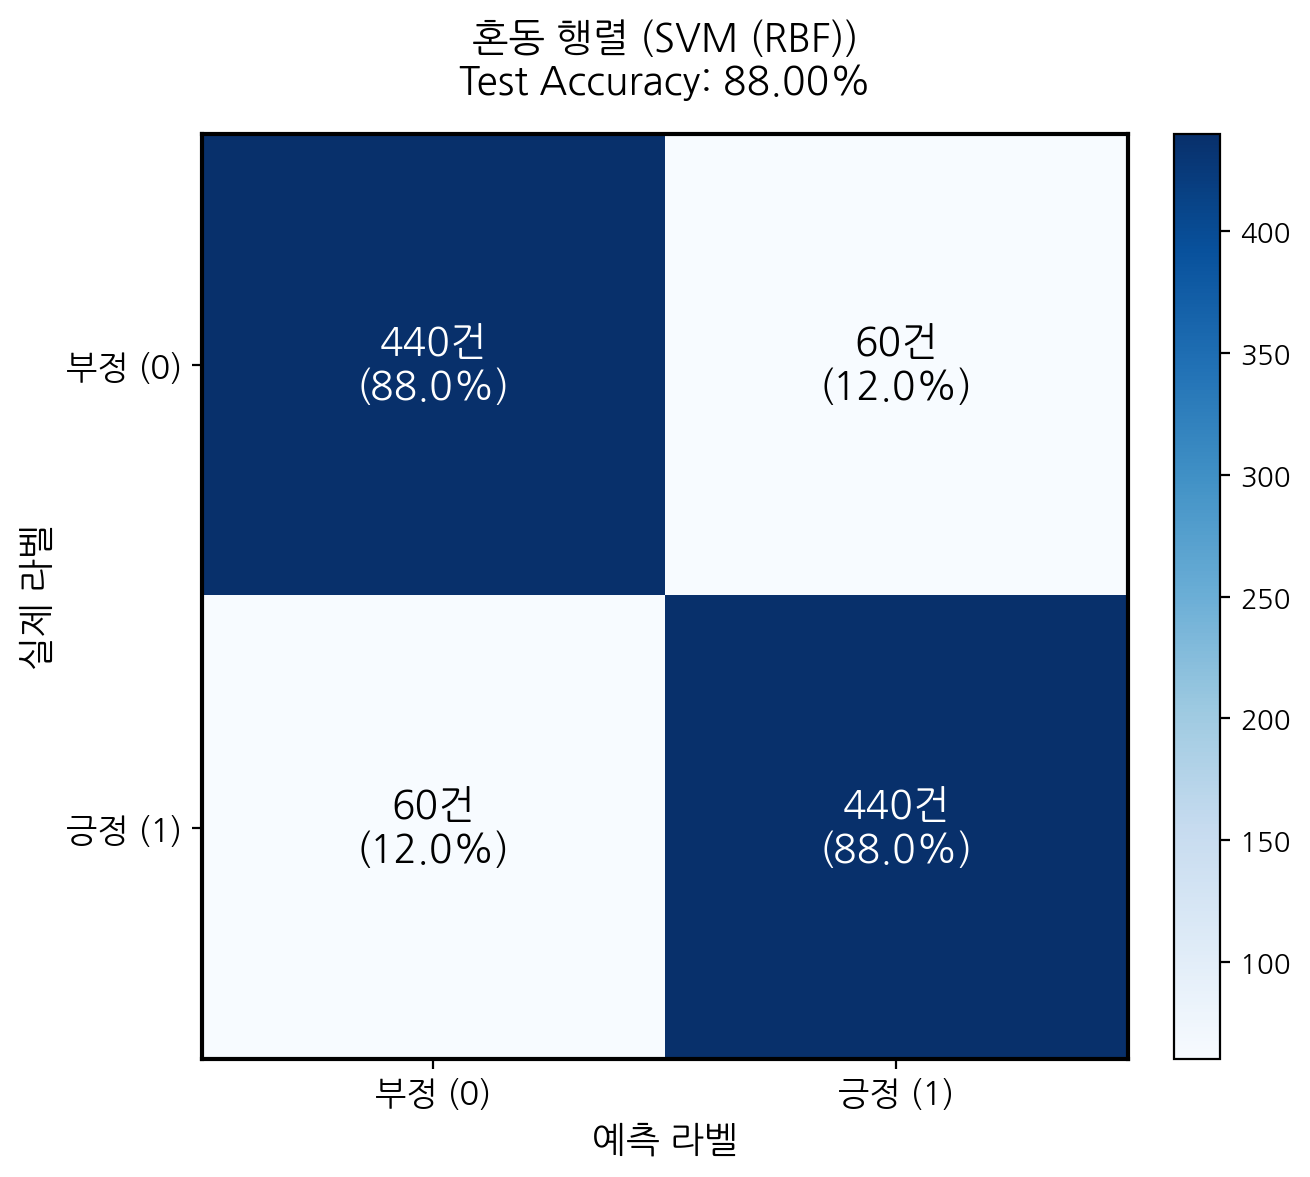

저장 완료: chart_03_confusion_matrix.png


In [123]:
# =============================================================================
# 발표자료 차트 3: 혼동 행렬 (발표용 고해상도)
# =============================================================================
# [의도] Test 데이터에 대한 혼동 행렬을 발표용 고해상도로 생성합니다.
#
# [왜 혼동 행렬이 중요한가?]
#   Accuracy만으로는 "어떤 유형의 오분류가 발생하는지" 파악할 수 없습니다.
#   예: Accuracy 90%라도, 부정 리뷰의 80%를 긍정으로 오분류한다면
#   실서비스에서 심각한 문제가 됩니다.
#   혼동 행렬은 이런 오분류 패턴을 2x2 행렬로 명확히 보여줍니다.
#
# [발표에서의 설명 포인트]
#   - 대각선 셀(TN, TP)이 클수록 정확한 모델
#   - 비대각선 셀(FP, FN)의 건수와 비율로 개선 방향 도출
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 6))

# Blues 컬러맵: 숫자가 클수록 진한 파란색으로 표시하여 직관적으로 구분합니다.
classes = ["부정 (0)", "긍정 (1)"]
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set(xticks=range(len(classes)), yticks=range(len(classes)),
       xticklabels=classes, yticklabels=classes)
ax.set_ylabel('실제 라벨', fontsize=13, fontweight='bold')
ax.set_xlabel('예측 라벨', fontsize=13, fontweight='bold')
ax.set_title(f'혼동 행렬 ({best_name})\nTest Accuracy: {acc_test:.2%}',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(labelsize=12)

# 각 셀에 건수와 비율을 동시에 표시합니다.
# 건수만으로는 전체 대비 비중을 파악하기 어려우므로 %(행 기준)도 함께 표시합니다.
thresh = cm.max() / 2.
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = count / cm[i].sum() * 100  # 행 기준 비율 (실제 라벨 기준)
        ax.text(j, i, f'{count}건\n({pct:.1f}%)',
                ha="center", va="center",
                # 배경이 진한 셀은 흰색, 연한 셀은 검정색 텍스트로 가독성 확보
                color="white" if count > thresh else "black",
                fontsize=14, fontweight='bold')

# 테두리를 강조하여 차트의 완성도를 높입니다.
for edge, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig('chart_03_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("저장 완료: chart_03_confusion_matrix.png")


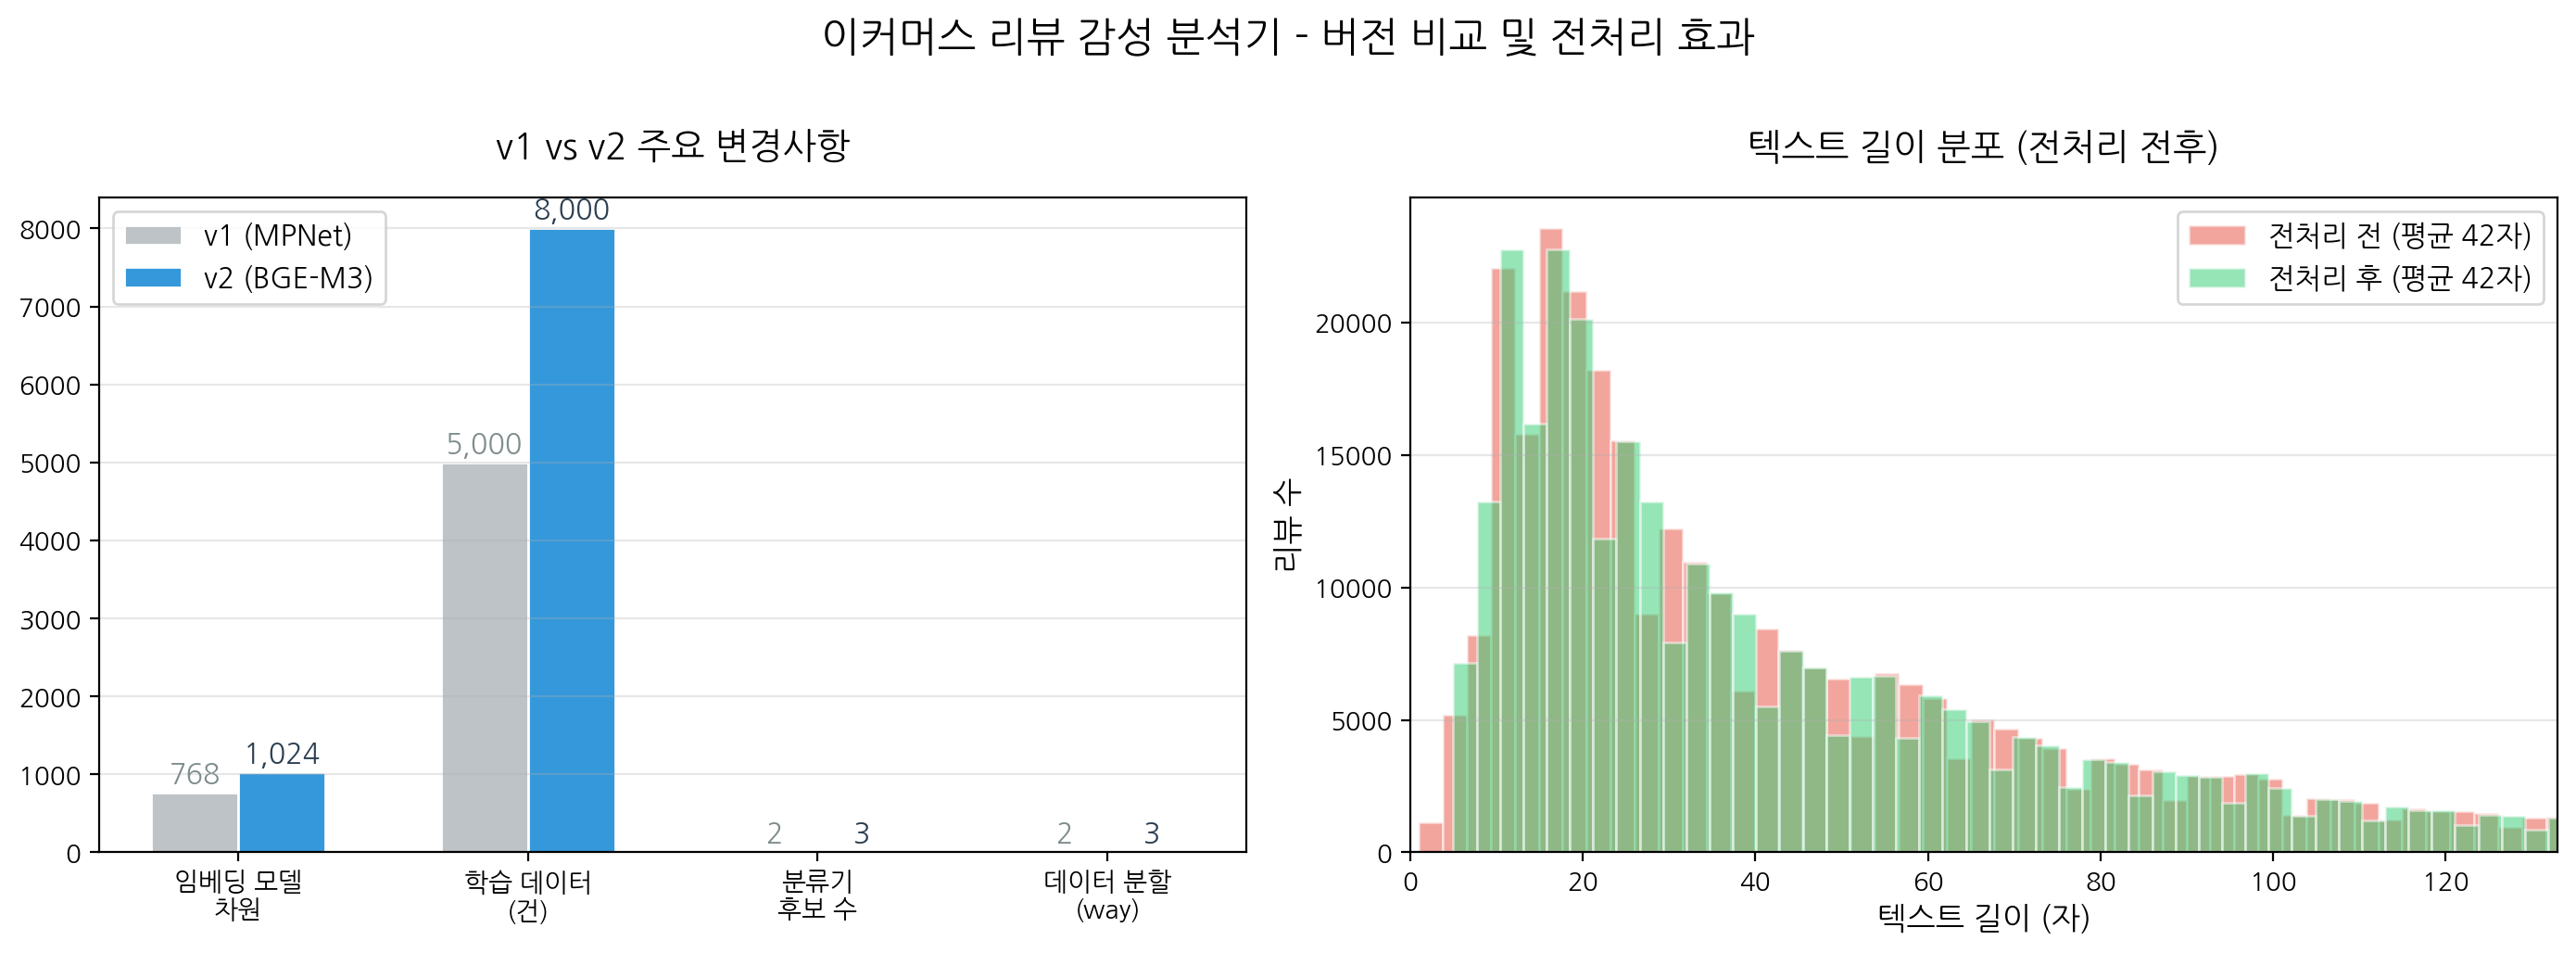

저장 완료: chart_04_version_comparison.png


In [124]:
# =============================================================================
# 발표자료 차트 4: v1 vs v2 비교 + 텍스트 길이 분포
# =============================================================================
# [의도] v1(이전 버전)과 v2(현재 버전)의 개선 사항을 정량적으로 비교합니다.
# 청중에게 "왜 v2를 만들었는지", "무엇이 개선되었는지"를 설명하는 핵심 차트입니다.
#
# [v1 → v2 주요 변경사항]
#   1) 임베딩 모델: ko-sroberta → E5 (문맥 이해력 향상)
#   2) 학습 데이터: 5,000건 → 8,000건 (60% 증가)
#   3) 분류기: 2종(LR, SVM) → 3종(LR, SVM, XGBoost)
#   4) 데이터 분할: 2-way → 3-way (Validation 추가)
#
# [왜 v1 비교가 필요한가?]
#   개선 작업의 효과를 객관적으로 입증하기 위해서는
#   이전 버전과의 비교가 필수적입니다.
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─────────────────────────────────────────────────
# (1) v1 vs v2 주요 지표 비교
# ─────────────────────────────────────────────────
# [판단 근거] 임베딩 차원, 학습 데이터 수, 분류기 후보 수, 분할 방식 등
# 정량적으로 비교 가능한 주요 지표를 나란히 배치합니다.
# 같은 차원(768)이지만 모델 자체가 다르다는 것, 데이터와 전략이 확장되었다는 것을 강조합니다.
categories = ['임베딩 모델\n차원', '학습 데이터\n(건)', '분류기\n후보 수', '데이터 분할\n(way)']
v1_values = [768, 5000, 2, 2]   # v1: MPNet 기반, 5K, LR+SVM, Train/Test
v2_values = [1024, 8000, 3, 3]   # v2: BGE-M3 기반, 8K, LR+SVM+XGB, Train/Val/Test

x = np.arange(len(categories))
width = 0.3

# 그룹화된 막대 차트: v1(회색)과 v2(파랑)를 나란히 배치하여 직관적 비교
bars1 = axes[0].bar(x - width/2, v1_values, width, label='v1 (MPNet)', color='#BDC3C7', edgecolor='white')
bars2 = axes[0].bar(x + width/2, v2_values, width, label='v2 (BGE-M3)', color='#3498DB', edgecolor='white')

for bar, val in zip(bars1, v1_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#7F8C8D')
for bar, val in zip(bars2, v2_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2C3E50')

axes[0].set_title('v1 vs v2 주요 변경사항', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, fontsize=10)
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────────────
# (2) 텍스트 길이 분포 (전처리 전후)
# ─────────────────────────────────────────────────
# [판단 근거] 전처리가 텍스트 길이 분포에 미친 영향을 오버레이 히스토그램으로 보여줍니다.
# 전처리 후에도 분포의 전체 형태가 유지되면서 극히 짧은 텍스트만 제거되었음을 확인합니다.
# 발표에서 "전처리가 데이터를 훼손하지 않았다"는 근거로 활용합니다.
raw_lengths = raw_df["text"].astype(str).str.len()
clean_lengths = clean_df["text"].astype(str).str.len()

axes[1].hist(raw_lengths, bins=50, alpha=0.5, label=f'전처리 전 (평균 {raw_lengths.mean():.0f}자)',
             color='#E74C3C', edgecolor='white')
axes[1].hist(clean_lengths, bins=50, alpha=0.5, label=f'전처리 후 (평균 {clean_lengths.mean():.0f}자)',
             color='#2ECC71', edgecolor='white')
axes[1].set_title('텍스트 길이 분포 (전처리 전후)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('텍스트 길이 (자)', fontsize=12)
axes[1].set_ylabel('리뷰 수', fontsize=12)
axes[1].legend(fontsize=11)
# 99번째 백분위수를 기준으로 X축 범위를 설정하여 분포를 선명하게 표시합니다.
axes[1].set_xlim(0, int(raw_lengths.quantile(0.99)))
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('이커머스 리뷰 감성 분석기 - 버전 비교 및 전처리 효과', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_04_version_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("저장 완료: chart_04_version_comparison.png")


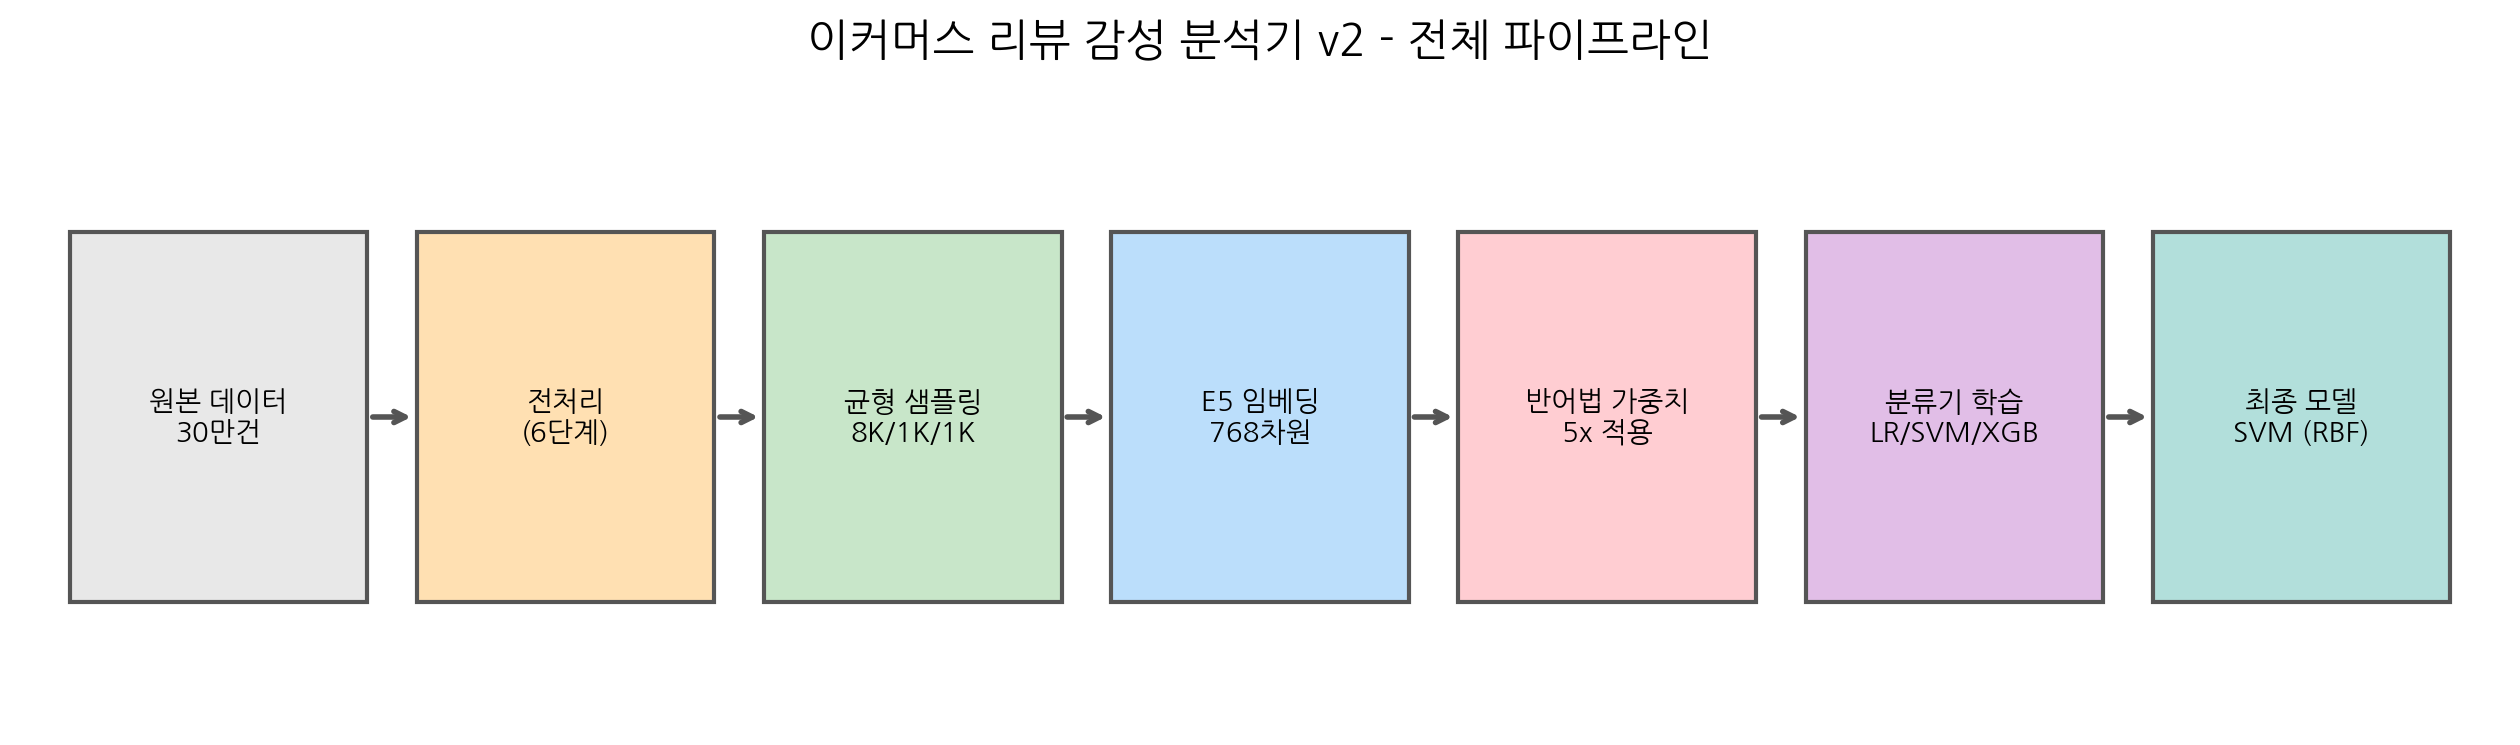

저장 완료: chart_05_pipeline.png

모든 발표자료 차트가 현재 디렉토리에 저장되었습니다.
파일 목록: chart_01 ~ chart_05


In [125]:
# =============================================================================
# 발표자료 차트 5: 파이프라인 전체 흐름도 (텍스트 기반)
# =============================================================================
# [의도] 이 프로젝트의 전체 처리 과정을 한 장의 흐름도로 요약합니다.
# 발표 마지막에 "전체를 되돌아보는 슬라이드"로 활용하거나,
# 발표 첫 장에 "오늘 할 내용 미리보기"로 사용할 수 있습니다.
#
# [왜 흐름도인가?]
#   코드와 수치로는 전체 과정의 맥락을 파악하기 어렵습니다.
#   7단계를 순서대로 시각화하여 청중이 프로젝트의 전체 구조를 이해할 수 있게 합니다.
#
# [단계별 색상 구분]
#   각 단계에 다른 색상을 적용하여 시각적으로 구분합니다.
#   데이터(회색) → 전처리(주황) → 샘플링(초록) → 임베딩(파랑) →
#   가중치(빨강) → 학습(보라) → 최종 모델(청록)
# =============================================================================
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')  # 축과 눈금을 숨겨 깔끔한 다이어그램 형태를 만듭니다.

# 파이프라인 7단계를 (라벨, 배경색) 쌍으로 정의합니다.
# 각 단계의 핵심 정보(데이터 수, 차원, 모델명)를 간결하게 표시합니다.
steps = [
    ('원본 데이터\n30만건', '#E8E8E8'),
    ('전처리\n(6단계)', '#FFE0B2'),
    ('균형 샘플링\n8K/1K/1K', '#C8E6C9'),
    ('E5 임베딩\n768차원', '#BBDEFB'),
    ('반어법 가중치\n5x 적용', '#FFCDD2'),
    (f'분류기 학습\nLR/SVM/XGB', '#E1BEE7'),
    (f'최종 모델\n{best_name}', '#B2DFDB'),
]

# 각 박스의 크기와 위치를 계산합니다.
box_width = 0.12
box_height = 0.6
y_center = 0.5
start_x = 0.02
gap = (1 - start_x * 2 - box_width * len(steps)) / (len(steps) - 1) + box_width

for i, (label, color) in enumerate(steps):
    x = start_x + i * gap
    # 각 단계를 둥근 사각형으로 그립니다.
    rect = plt.Rectangle((x, y_center - box_height/2), box_width, box_height,
                          facecolor=color, edgecolor='#555555', linewidth=1.5,
                          transform=ax.transAxes, clip_on=False, zorder=2)
    ax.add_patch(rect)
    # 박스 중앙에 단계명을 표시합니다.
    ax.text(x + box_width/2, y_center, label,
            transform=ax.transAxes, ha='center', va='center',
            fontsize=10, fontweight='bold', zorder=3)

    # 단계 사이에 화살표를 그려 흐름을 표현합니다.
    if i < len(steps) - 1:
        arrow_x = x + box_width
        arrow_end = start_x + (i + 1) * gap
        ax.annotate('', xy=(arrow_end, y_center), xytext=(arrow_x, y_center),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#555555', lw=2))

ax.set_title('이커머스 리뷰 감성 분석기 v2 - 전체 파이프라인',
             fontsize=16, fontweight='bold', pad=20)
plt.savefig('chart_05_pipeline.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("저장 완료: chart_05_pipeline.png")
print("\n모든 발표자료 차트가 현재 디렉토리에 저장되었습니다.")
print("파일 목록: chart_01 ~ chart_05")
